<a href="https://colab.research.google.com/github/Eng-MIR/DEPI4-CCPA/blob/main/Milestone_1_%26_2_Customer_Churn_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Exploration and Preparation

In [ ]:
# Mounting drive
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/DEPI R4/My_Final Project/WA_Fn-UseC_-Telco-Customer-Churn.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data = pd.read_csv(file_path)
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.shape

(7043, 21)

In [ ]:
# Check for duplicates
duplicate_count = data["customerID"].duplicated().sum()

print("Number of duplicated customerIDs:", duplicate_count)


Number of duplicated customerIDs: 0


In [ ]:
# Drop customerID (not useful for modeling)
data.drop("customerID", axis=1, inplace=True)
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
data.describe(include="all")

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [ ]:
# Convert SeniorCitizen to categorical
data["SeniorCitizen"] = data["SeniorCitizen"].astype("category")

In [ ]:
# Convert TotalCharges to numeric (it has some spaces)
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            7043 non-null   object  
 1   SeniorCitizen     7043 non-null   category
 2   Partner           7043 non-null   object  
 3   Dependents        7043 non-null   object  
 4   tenure            7043 non-null   int64   
 5   PhoneService      7043 non-null   object  
 6   MultipleLines     7043 non-null   object  
 7   InternetService   7043 non-null   object  
 8   OnlineSecurity    7043 non-null   object  
 9   OnlineBackup      7043 non-null   object  
 10  DeviceProtection  7043 non-null   object  
 11  TechSupport       7043 non-null   object  
 12  StreamingTV       7043 non-null   object  
 13  StreamingMovies   7043 non-null   object  
 14  Contract          7043 non-null   object  
 15  PaperlessBilling  7043 non-null   object  
 16  PaymentMethod     7043 n

In [ ]:
data.dtypes

,0
gender,object
SeniorCitizen,category
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [ ]:
data.describe(include="all")

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043.0,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032.000000,7043
unique,2,2.0,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,Male,0.0,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,3555,5901.0,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2283.300441,NaN
std,NaN,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.771362,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.450000,NaN
50%,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,NaN


In [ ]:

# Count NaN values per column
nan_counts = data.isna().sum()

# Show only columns that actually have NaNs
nan_columns = nan_counts[nan_counts > 0]

print("Columns with NaN values:\n")
print(nan_columns)

Columns with NaN values:

TotalCharges    11
dtype: int64


In [ ]:
# Handle missing values (few rows become NaN after conversion)
data.dropna(inplace=True)

In [ ]:
data.isna().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
# Columns to exclude
exclude_cols = ["MonthlyCharges", "TotalCharges", "tenure"]

# Loop through columns
for col in data.columns:
    if col not in exclude_cols:
        print(f"\n# Column: {col}")
        print(f"Unique values ({data[col].nunique()}):")
        print(data[col].unique())


# Column: gender
Unique values (2):
['Female' 'Male']

# Column: SeniorCitizen
Unique values (2):
[0, 1]
Categories (2, int64): [0, 1]

# Column: Partner
Unique values (2):
['Yes' 'No']

# Column: Dependents
Unique values (2):
['No' 'Yes']

# Column: PhoneService
Unique values (2):
['No' 'Yes']

# Column: MultipleLines
Unique values (3):
['No phone service' 'No' 'Yes']

# Column: InternetService
Unique values (3):
['DSL' 'Fiber optic' 'No']

# Column: OnlineSecurity
Unique values (3):
['No' 'Yes' 'No internet service']

# Column: OnlineBackup
Unique values (3):
['Yes' 'No' 'No internet service']

# Column: DeviceProtection
Unique values (3):
['No' 'Yes' 'No internet service']

# Column: TechSupport
Unique values (3):
['No' 'Yes' 'No internet service']

# Column: StreamingTV
Unique values (3):
['No' 'Yes' 'No internet service']

# Column: StreamingMovies
Unique values (3):
['No' 'Yes' 'No internet service']

# Column: Contract
Unique values (3):
['Month-to-month' 'One year' 'Two year']

## Categorical Data Visualizations

In [ ]:
def pie_summary(df, column, title, label_map=None, order=None, legend_title=None, figsize=(8, 8)):
    counts = df[column].astype(str).value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order, fill_value=0)

    category_labels = counts.index.to_series()
    if label_map is not None:
        category_labels = category_labels.map(lambda x: label_map.get(x, x))

    total = counts.sum()
    inner_labels = [f"{count} ({round(count / total * 100)}%)" for count in counts]

    fig, ax = plt.subplots(figsize=figsize)
    wedges, _ = ax.pie(counts.values, startangle=90)
    ax.legend(
        wedges,
        category_labels.tolist(),
        title=legend_title or column,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )

    for wedge, txt in zip(wedges, inner_labels):
        angle = (wedge.theta1 + wedge.theta2) / 2
        x = 0.6 * np.cos(np.deg2rad(angle))
        y = 0.6 * np.sin(np.deg2rad(angle))
        ax.text(x, y, txt, ha="center", va="center")

    ax.set_title(title, loc="center", fontweight="bold")
    plt.tight_layout()
    plt.show()


def stacked_churn_percent(df, column, title, xlabel, label_map=None, order=None, figsize=(9, 5)):
    summary = pd.crosstab(df[column].astype(str), df["Churn"].astype(str), normalize="index") * 100

    if order is not None:
        summary = summary.reindex(order, fill_value=0)

    display_index = summary.index.tolist()
    if label_map is not None:
        display_index = [label_map.get(x, x) for x in display_index]
    summary.index = display_index

    preferred_cols = [c for c in ["No", "Yes", "0", "1"] if c in summary.columns]
    remaining_cols = [c for c in summary.columns if c not in preferred_cols]
    summary = summary[preferred_cols + remaining_cols]

    fig, ax = plt.subplots(figsize=figsize)
    bottom = np.zeros(len(summary))

    for churn_value in summary.columns:
        values = summary[churn_value].values
        bars = ax.bar(summary.index, values, bottom=bottom, label=churn_value)
        for i, value in enumerate(values):
            if value > 0:
                ax.text(i, bottom[i] + value / 2, f"{round(value)}%", ha="center", va="center")
        bottom += values

    ax.set_title(title, loc="center", fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Percentage")
    ax.legend(title="Churn")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

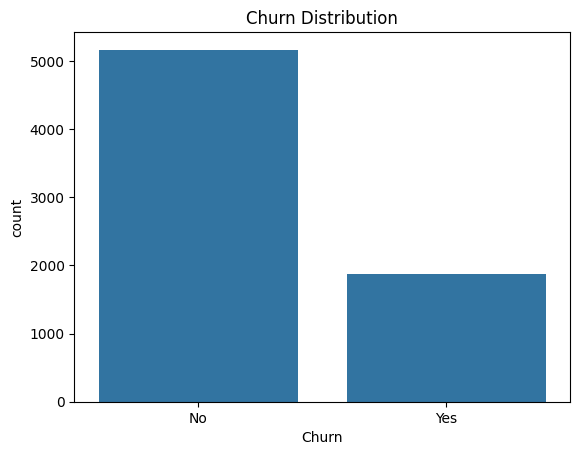

In [ ]:

#Target Distribution

plt.figure()
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

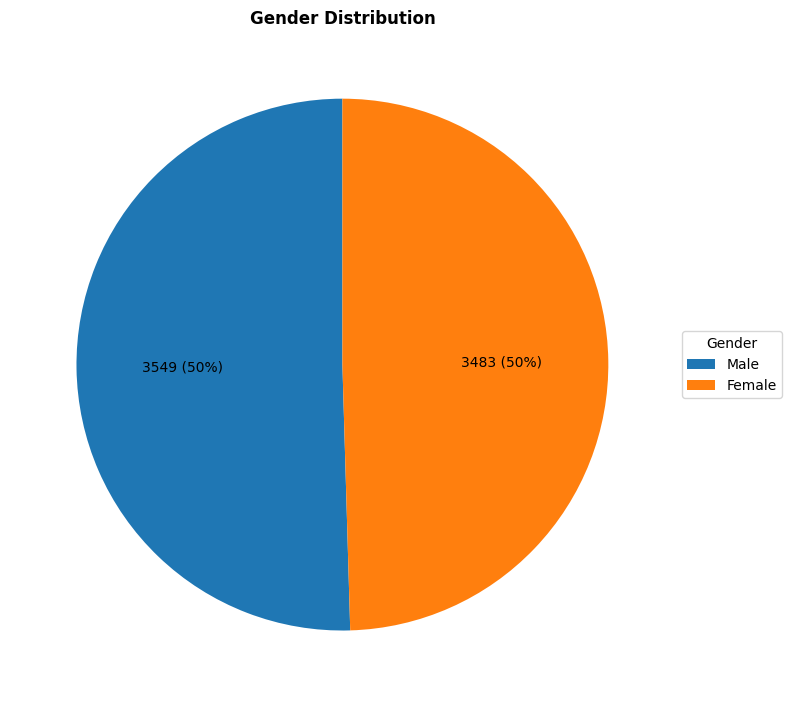

In [ ]:
pie_summary(
    data,
    column="gender",
    title="Gender Distribution",
    label_map=None,
    order=None,
    legend_title="Gender",
)

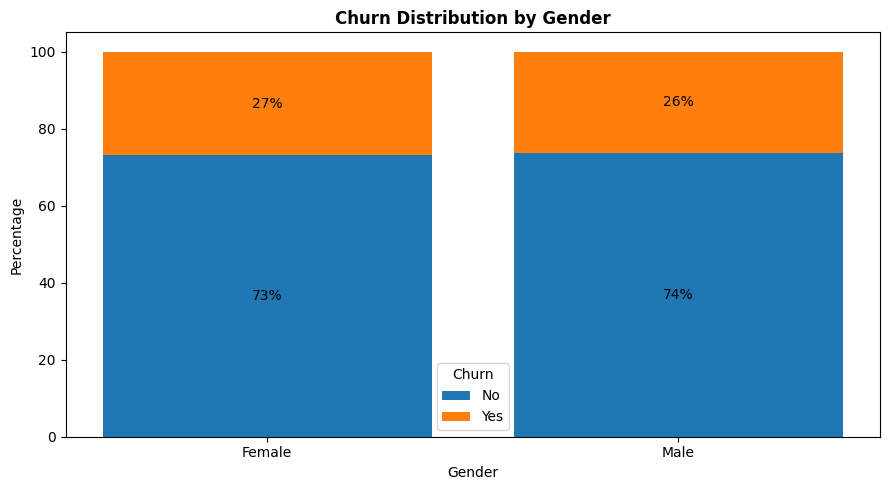

In [ ]:
stacked_churn_percent(
    data,
    column="gender",
    title="Churn Distribution by Gender",
    xlabel="Gender",
    label_map=None,
    order=None,
)

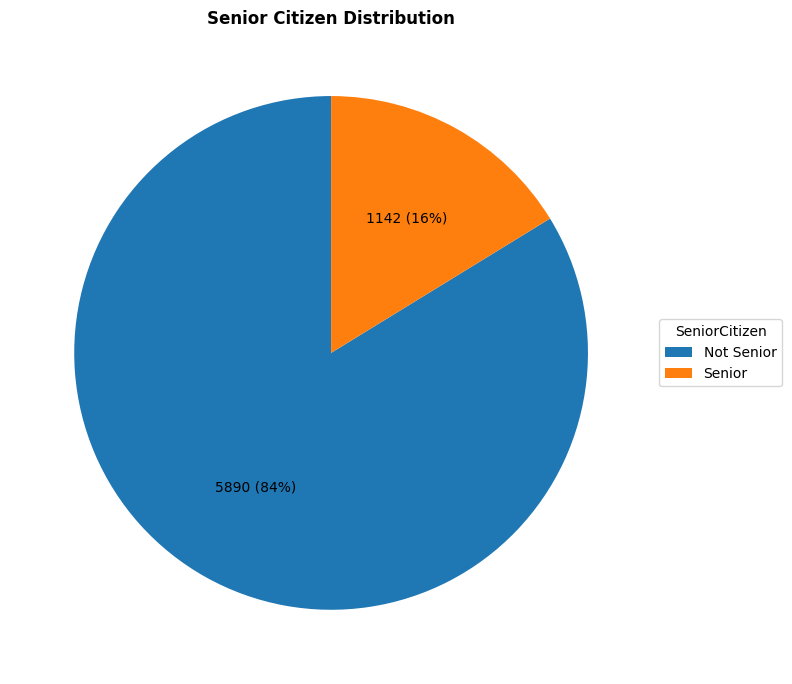

In [ ]:
pie_summary(
    data,
    column="SeniorCitizen",
    title="Senior Citizen Distribution",
    label_map={'0': 'Not Senior', '1': 'Senior'},
    order=['0', '1'],
    legend_title="SeniorCitizen",
)

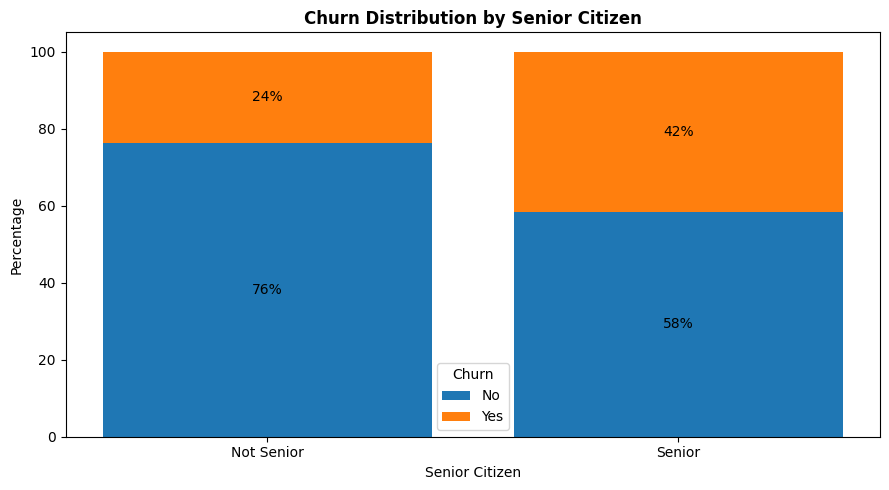

In [ ]:
stacked_churn_percent(
    data,
    column="SeniorCitizen",
    title="Churn Distribution by Senior Citizen",
    xlabel="Senior Citizen",
    label_map={'0': 'Not Senior', '1': 'Senior'},
    order=['0', '1'],
)

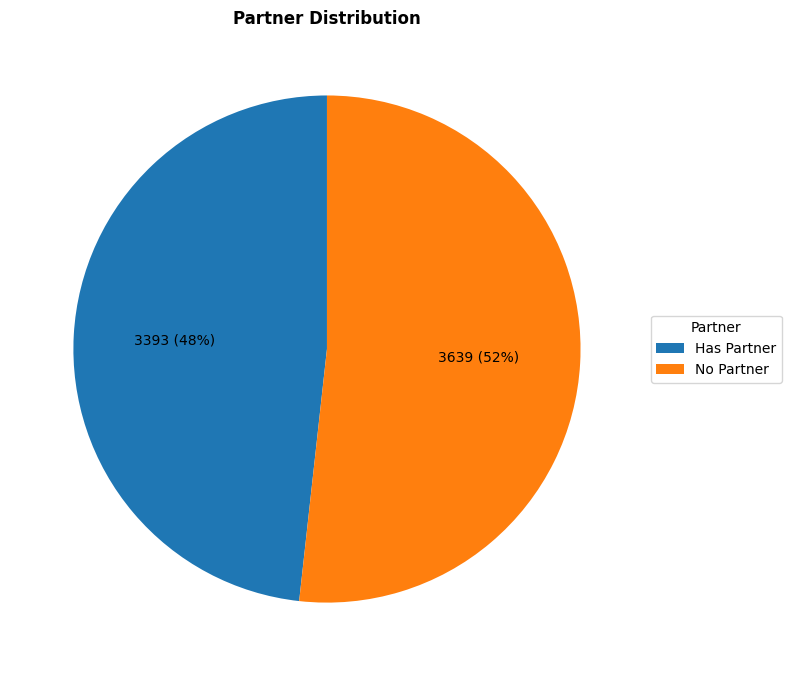

In [ ]:
pie_summary(
    data,
    column="Partner",
    title="Partner Distribution",
    label_map={'Yes': 'Has Partner', 'No': 'No Partner'},
    order=['Yes', 'No'],
    legend_title="Partner",
)

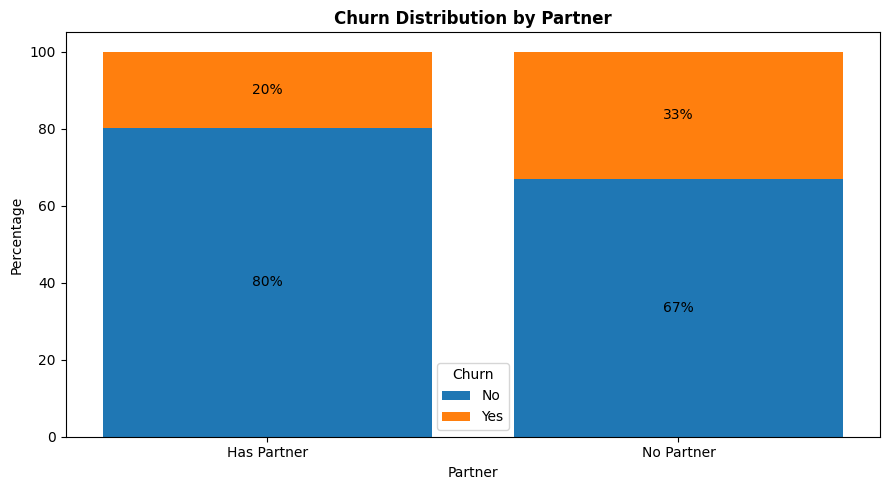

In [ ]:
stacked_churn_percent(
    data,
    column="Partner",
    title="Churn Distribution by Partner",
    xlabel="Partner",
    label_map={'Yes': 'Has Partner', 'No': 'No Partner'},
    order=['Yes', 'No'],
)

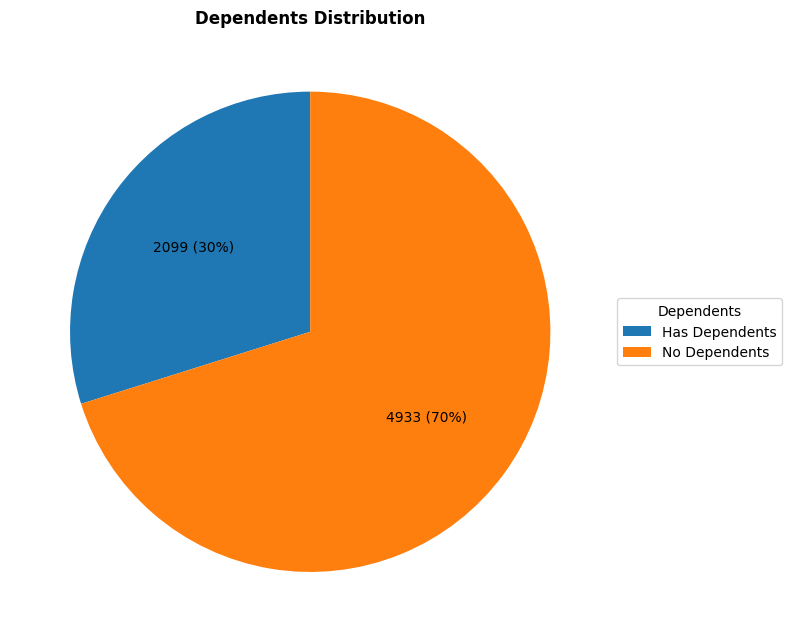

In [ ]:
pie_summary(
    data,
    column="Dependents",
    title="Dependents Distribution",
    label_map={'Yes': 'Has Dependents', 'No': 'No Dependents'},
    order=['Yes', 'No'],
    legend_title="Dependents",
)

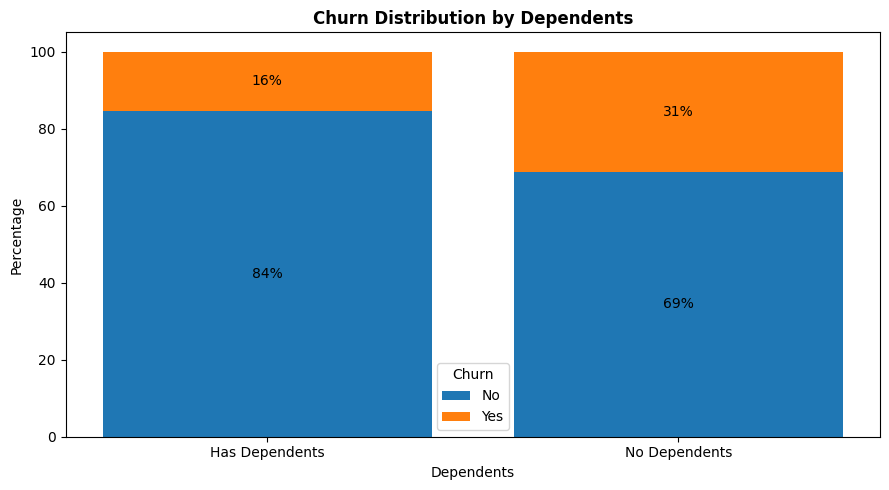

In [ ]:
stacked_churn_percent(
    data,
    column="Dependents",
    title="Churn Distribution by Dependents",
    xlabel="Dependents",
    label_map={'Yes': 'Has Dependents', 'No': 'No Dependents'},
    order=['Yes', 'No'],
)

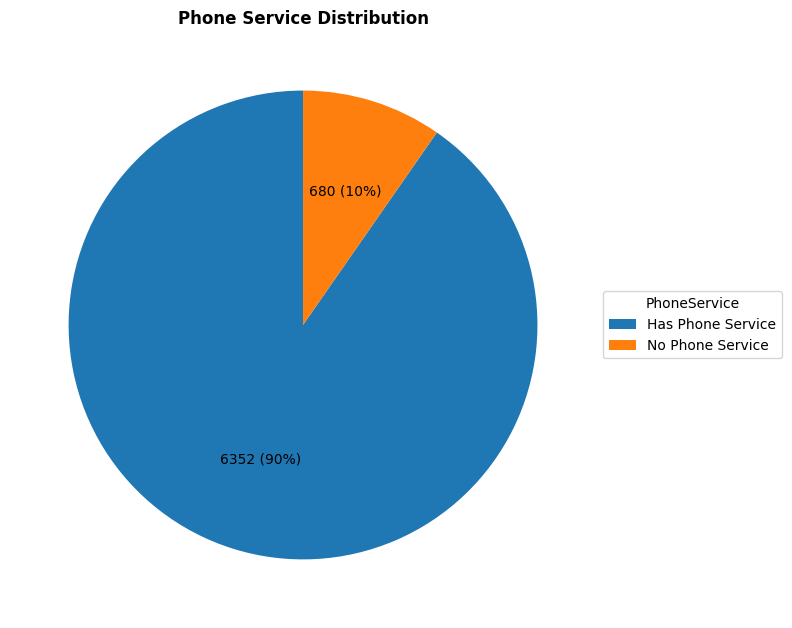

In [ ]:
pie_summary(
    data,
    column="PhoneService",
    title="Phone Service Distribution",
    label_map={'Yes': 'Has Phone Service', 'No': 'No Phone Service'},
    order=['Yes', 'No'],
    legend_title="PhoneService",
)

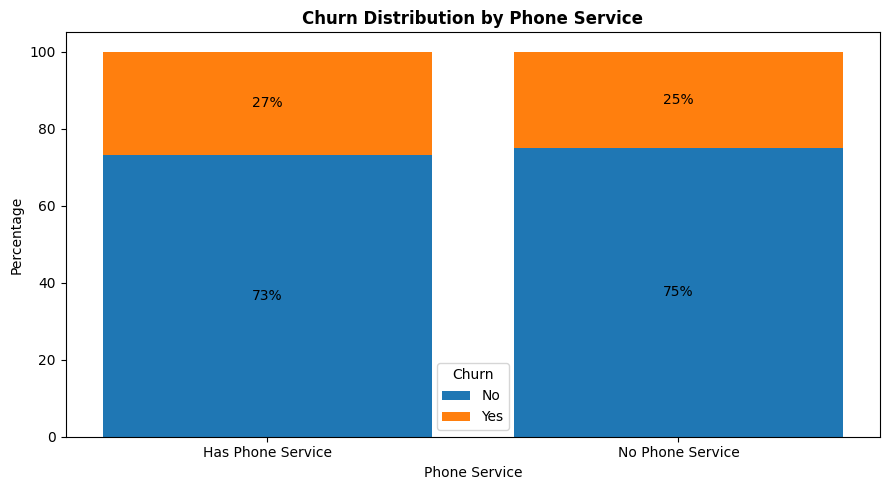

In [ ]:
stacked_churn_percent(
    data,
    column="PhoneService",
    title="Churn Distribution by Phone Service",
    xlabel="Phone Service",
    label_map={'Yes': 'Has Phone Service', 'No': 'No Phone Service'},
    order=['Yes', 'No'],
)

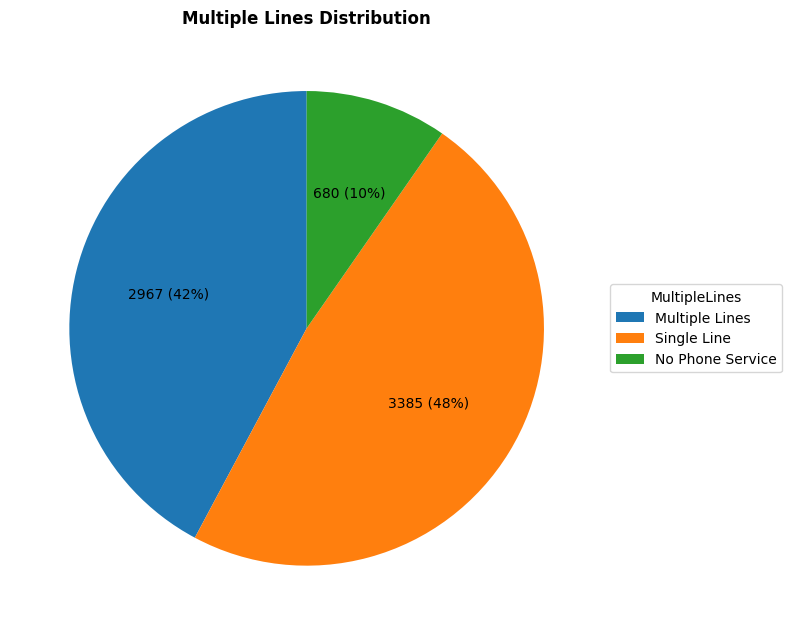

In [ ]:
pie_summary(
    data,
    column="MultipleLines",
    title="Multiple Lines Distribution",
    label_map={'Yes': 'Multiple Lines', 'No': 'Single Line', 'No phone service': 'No Phone Service'},
    order=['Yes', 'No', 'No phone service'],
    legend_title="MultipleLines",
)

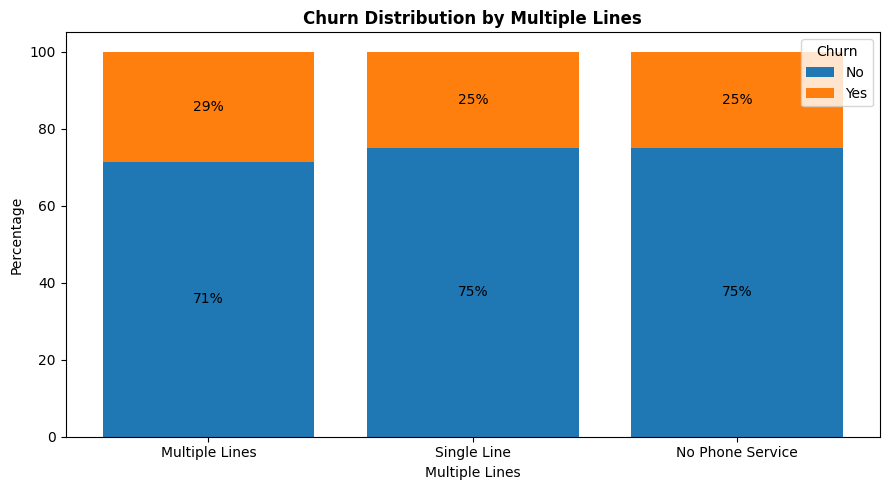

In [ ]:
stacked_churn_percent(
    data,
    column="MultipleLines",
    title="Churn Distribution by Multiple Lines",
    xlabel="Multiple Lines",
    label_map={'Yes': 'Multiple Lines', 'No': 'Single Line', 'No phone service': 'No Phone Service'},
    order=['Yes', 'No', 'No phone service'],
)

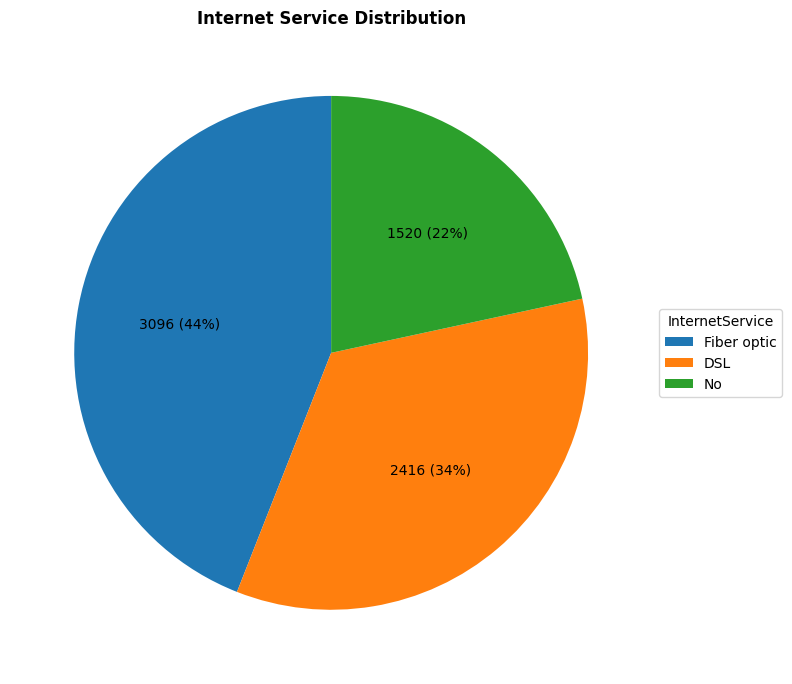

In [ ]:
pie_summary(
    data,
    column="InternetService",
    title="Internet Service Distribution",
    label_map=None,
    order=None,
    legend_title="InternetService",
)

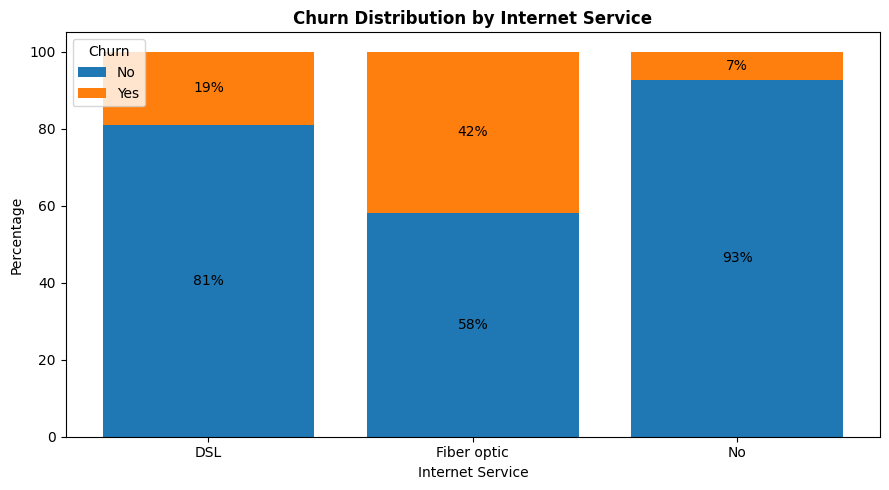

In [ ]:
stacked_churn_percent(
    data,
    column="InternetService",
    title="Churn Distribution by Internet Service",
    xlabel="Internet Service",
    label_map=None,
    order=None,
)

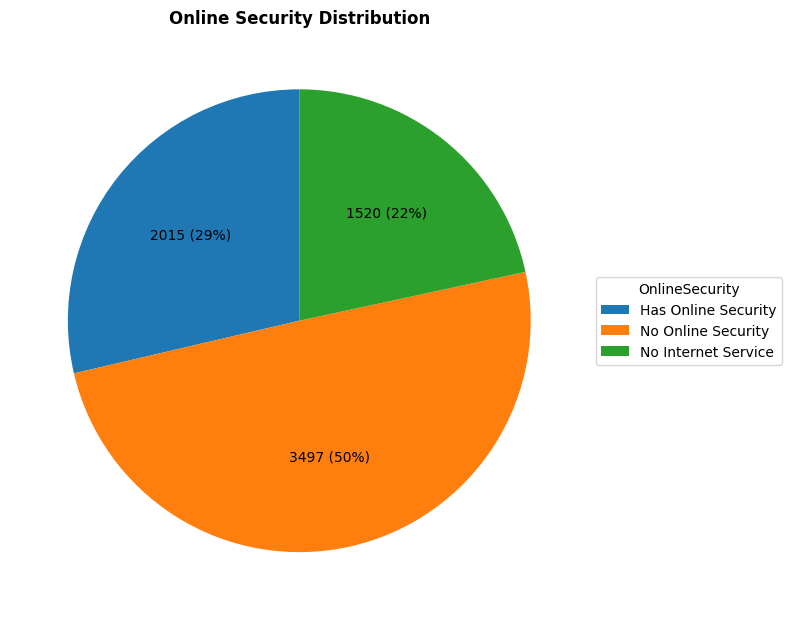

In [ ]:
pie_summary(
    data,
    column="OnlineSecurity",
    title="Online Security Distribution",
    label_map={'Yes': 'Has Online Security', 'No': 'No Online Security', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
    legend_title="OnlineSecurity",
)

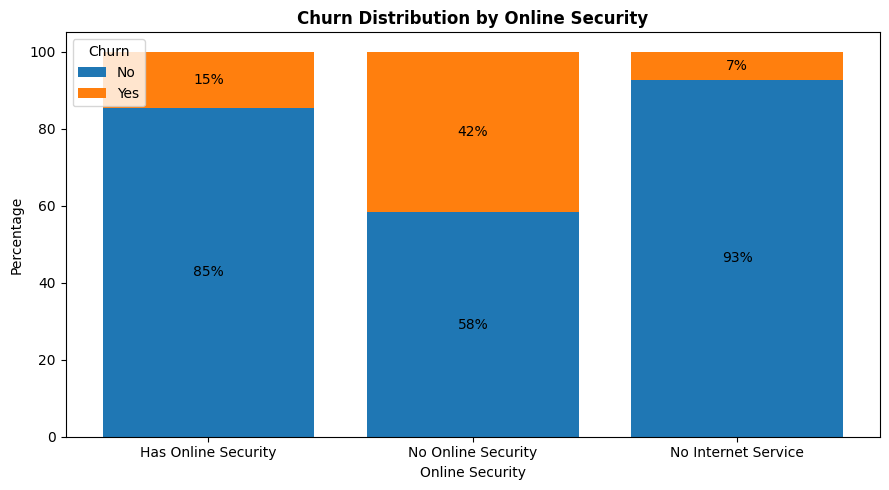

In [ ]:
stacked_churn_percent(
    data,
    column="OnlineSecurity",
    title="Churn Distribution by Online Security",
    xlabel="Online Security",
    label_map={'Yes': 'Has Online Security', 'No': 'No Online Security', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
)

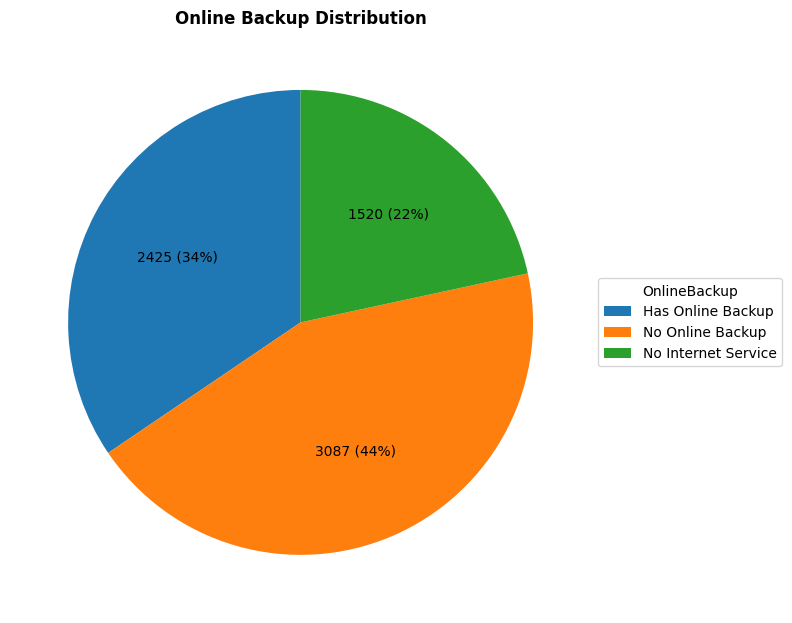

In [ ]:
pie_summary(
    data,
    column="OnlineBackup",
    title="Online Backup Distribution",
    label_map={'Yes': 'Has Online Backup', 'No': 'No Online Backup', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
    legend_title="OnlineBackup",
)

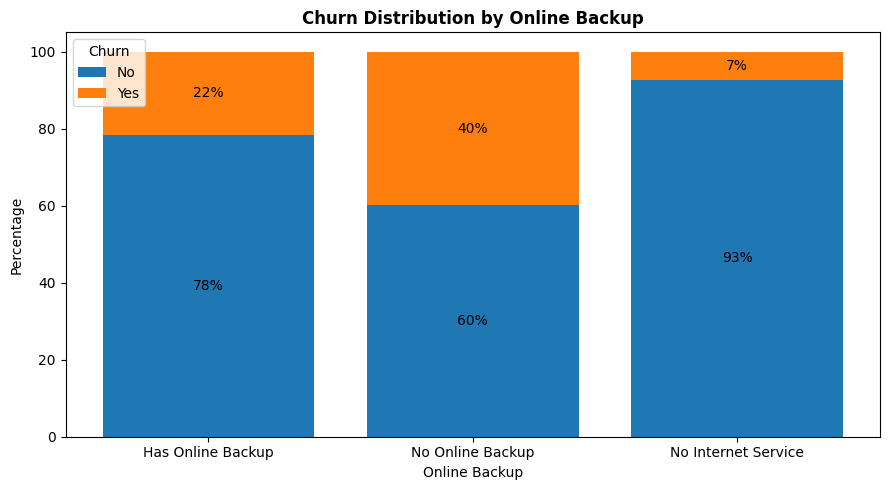

In [ ]:
stacked_churn_percent(
    data,
    column="OnlineBackup",
    title="Churn Distribution by Online Backup",
    xlabel="Online Backup",
    label_map={'Yes': 'Has Online Backup', 'No': 'No Online Backup', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
)

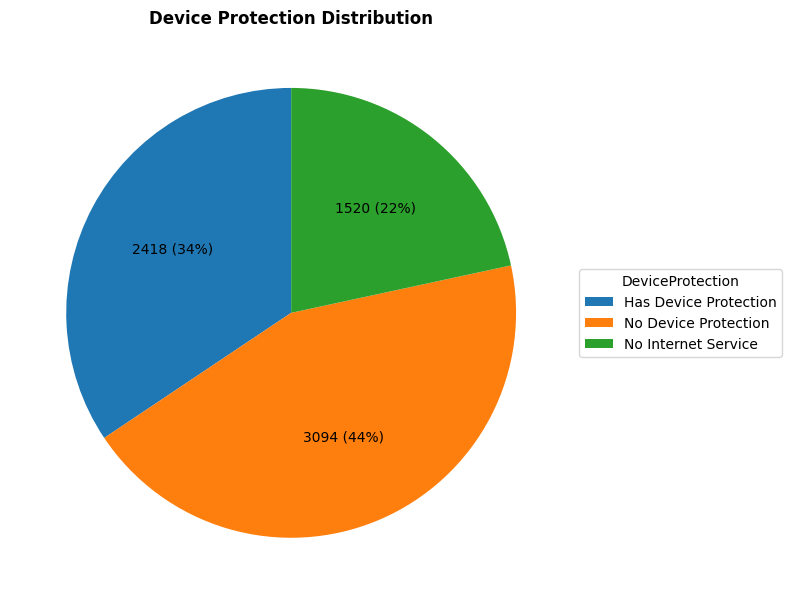

In [ ]:
pie_summary(
    data,
    column="DeviceProtection",
    title="Device Protection Distribution",
    label_map={'Yes': 'Has Device Protection', 'No': 'No Device Protection', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
    legend_title="DeviceProtection",
)

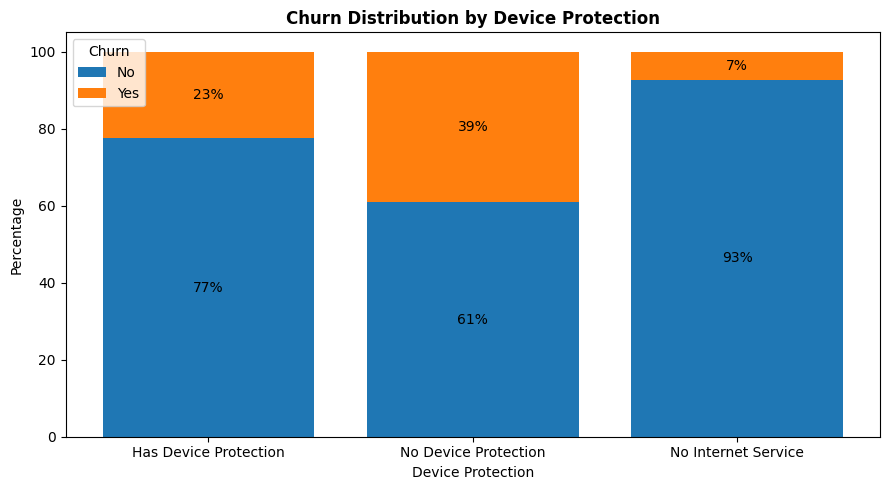

In [ ]:
stacked_churn_percent(
    data,
    column="DeviceProtection",
    title="Churn Distribution by Device Protection",
    xlabel="Device Protection",
    label_map={'Yes': 'Has Device Protection', 'No': 'No Device Protection', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
)

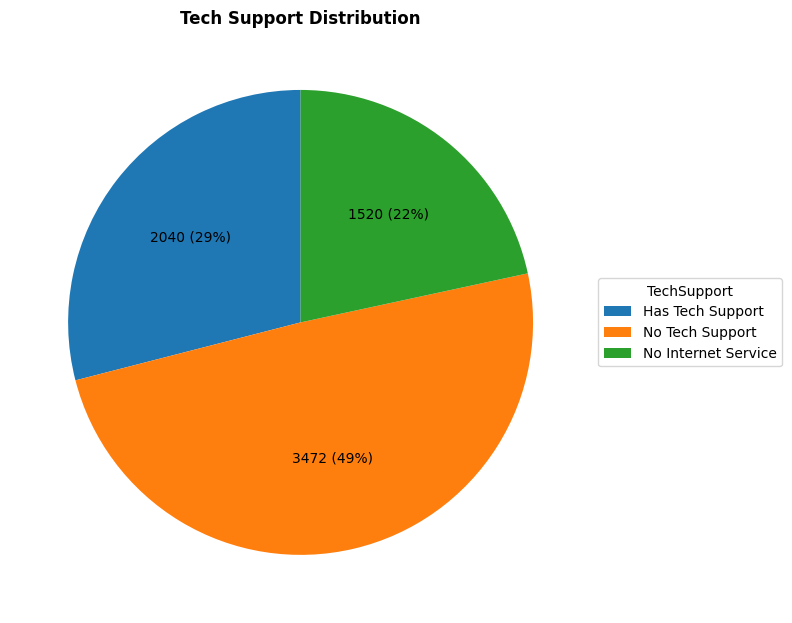

In [ ]:
pie_summary(
    data,
    column="TechSupport",
    title="Tech Support Distribution",
    label_map={'Yes': 'Has Tech Support', 'No': 'No Tech Support', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
    legend_title="TechSupport",
)

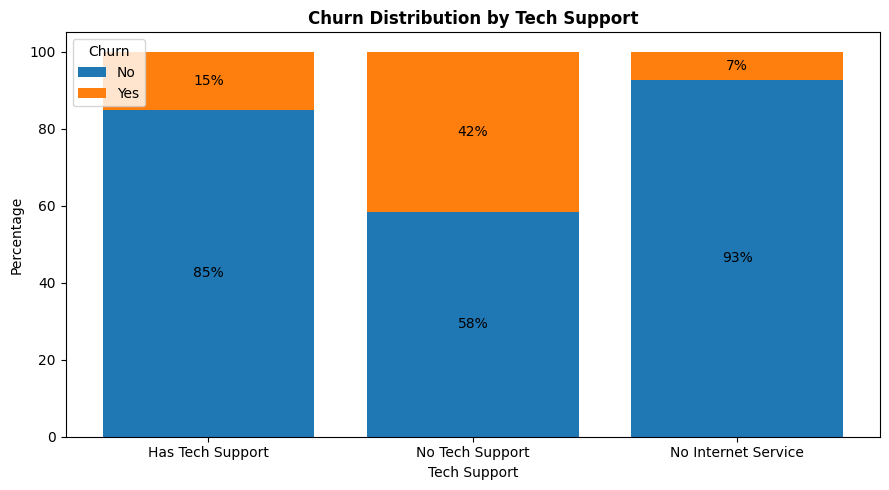

In [ ]:
stacked_churn_percent(
    data,
    column="TechSupport",
    title="Churn Distribution by Tech Support",
    xlabel="Tech Support",
    label_map={'Yes': 'Has Tech Support', 'No': 'No Tech Support', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
)

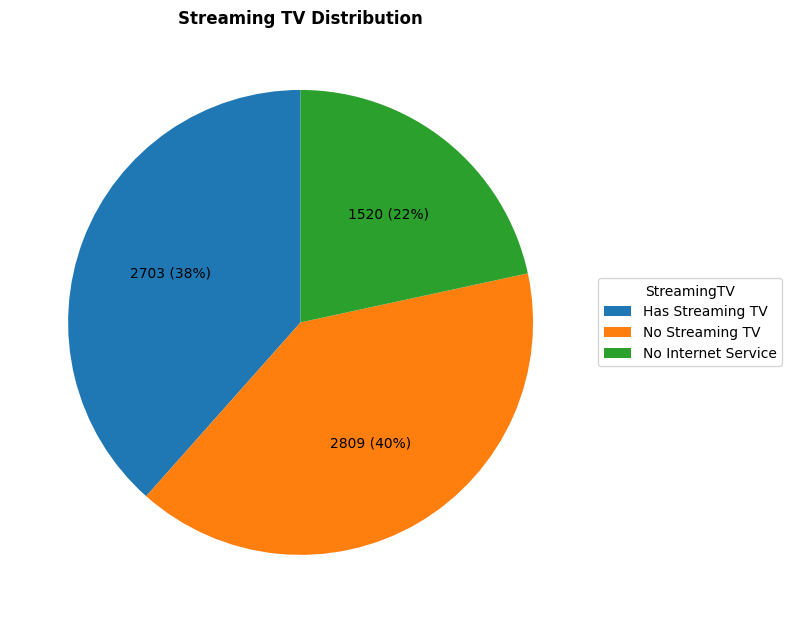

In [ ]:
pie_summary(
    data,
    column="StreamingTV",
    title="Streaming TV Distribution",
    label_map={'Yes': 'Has Streaming TV', 'No': 'No Streaming TV', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
    legend_title="StreamingTV",
)

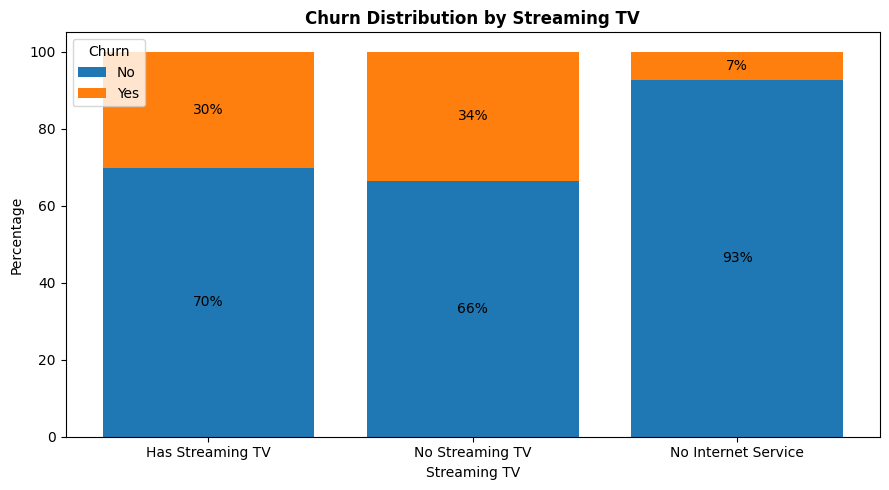

In [ ]:
stacked_churn_percent(
    data,
    column="StreamingTV",
    title="Churn Distribution by Streaming TV",
    xlabel="Streaming TV",
    label_map={'Yes': 'Has Streaming TV', 'No': 'No Streaming TV', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
)

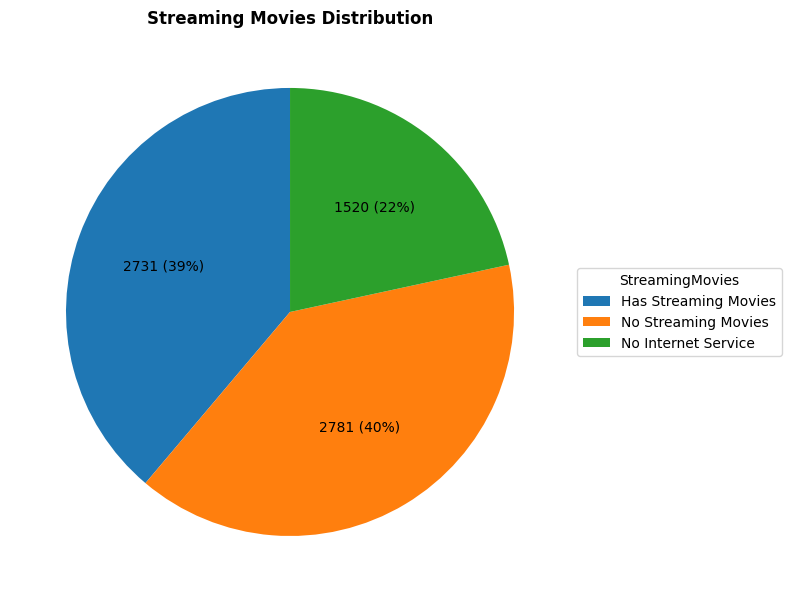

In [ ]:
pie_summary(
    data,
    column="StreamingMovies",
    title="Streaming Movies Distribution",
    label_map={'Yes': 'Has Streaming Movies', 'No': 'No Streaming Movies', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
    legend_title="StreamingMovies",
)

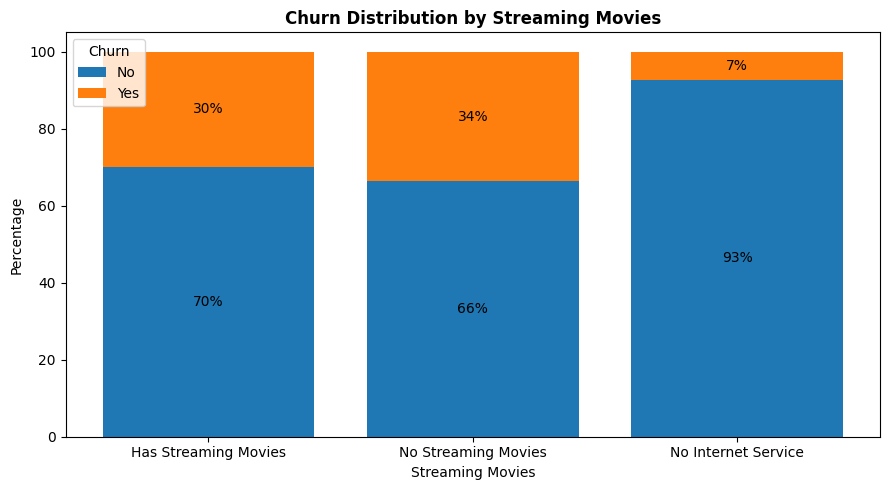

In [ ]:
stacked_churn_percent(
    data,
    column="StreamingMovies",
    title="Churn Distribution by Streaming Movies",
    xlabel="Streaming Movies",
    label_map={'Yes': 'Has Streaming Movies', 'No': 'No Streaming Movies', 'No internet service': 'No Internet Service'},
    order=['Yes', 'No', 'No internet service'],
)

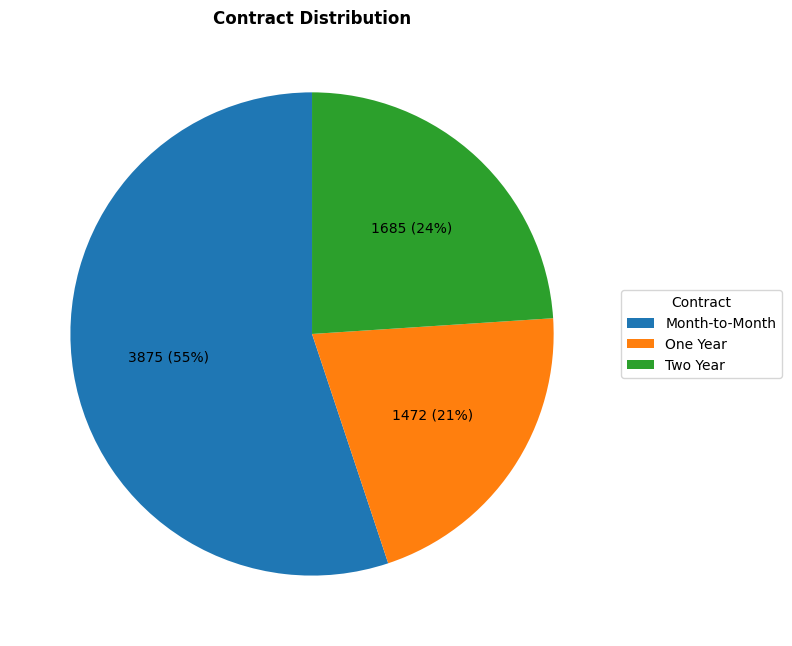

In [ ]:
pie_summary(
    data,
    column="Contract",
    title="Contract Distribution",
    label_map={'Month-to-month': 'Month-to-Month', 'One year': 'One Year', 'Two year': 'Two Year'},
    order=['Month-to-month', 'One year', 'Two year'],
    legend_title="Contract",
)

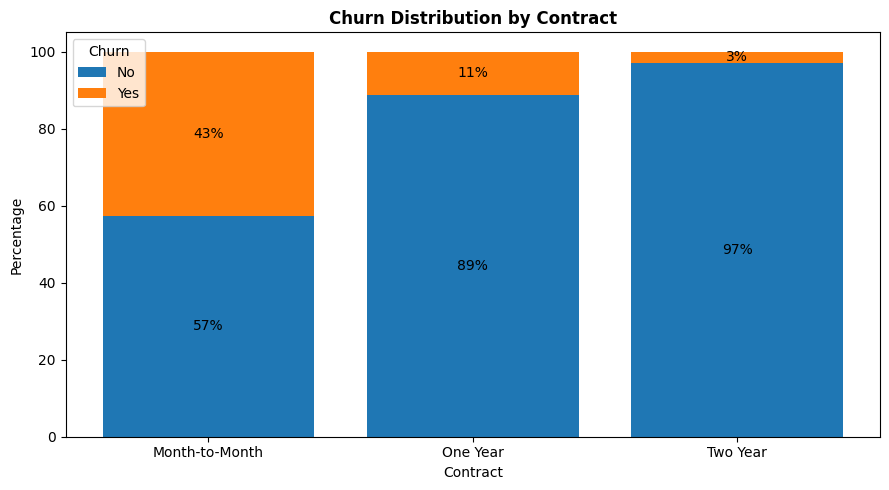

In [ ]:
stacked_churn_percent(
    data,
    column="Contract",
    title="Churn Distribution by Contract",
    xlabel="Contract",
    label_map={'Month-to-month': 'Month-to-Month', 'One year': 'One Year', 'Two year': 'Two Year'},
    order=['Month-to-month', 'One year', 'Two year'],
)

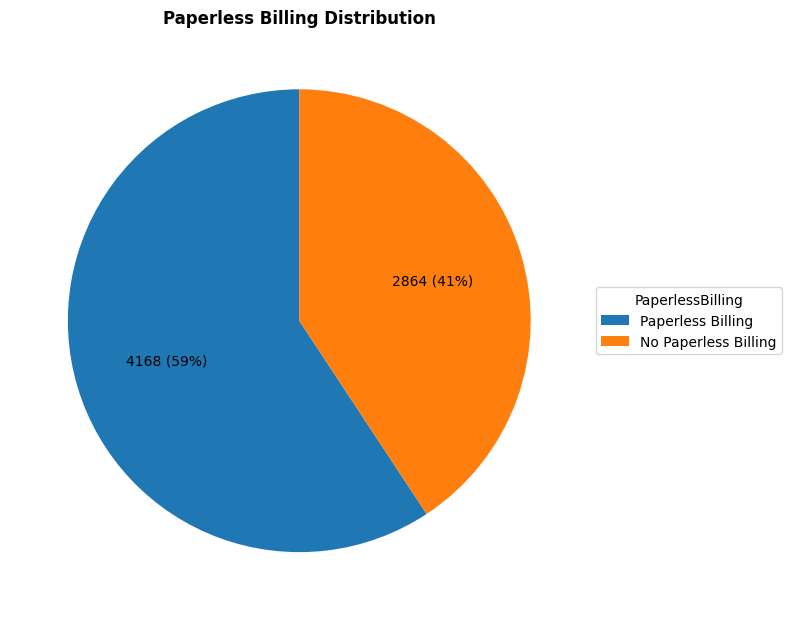

In [ ]:
pie_summary(
    data,
    column="PaperlessBilling",
    title="Paperless Billing Distribution",
    label_map={'Yes': 'Paperless Billing', 'No': 'No Paperless Billing'},
    order=['Yes', 'No'],
    legend_title="PaperlessBilling",
)

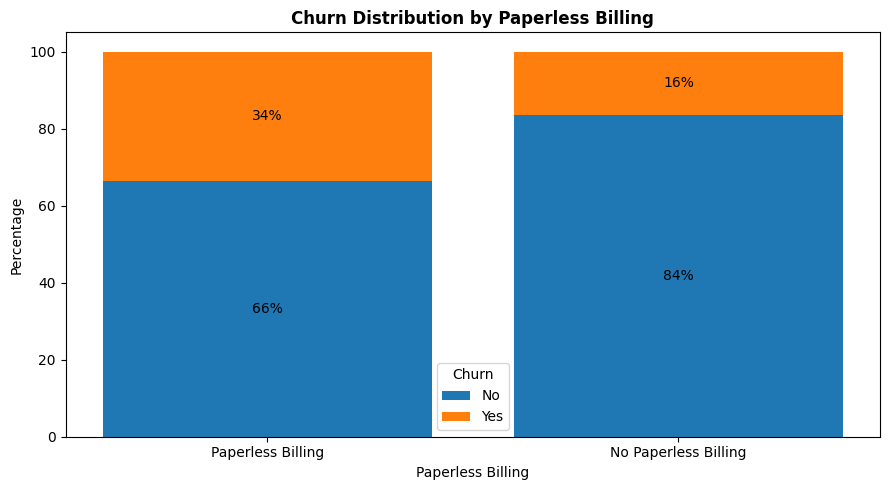

In [ ]:
stacked_churn_percent(
    data,
    column="PaperlessBilling",
    title="Churn Distribution by Paperless Billing",
    xlabel="Paperless Billing",
    label_map={'Yes': 'Paperless Billing', 'No': 'No Paperless Billing'},
    order=['Yes', 'No'],
)

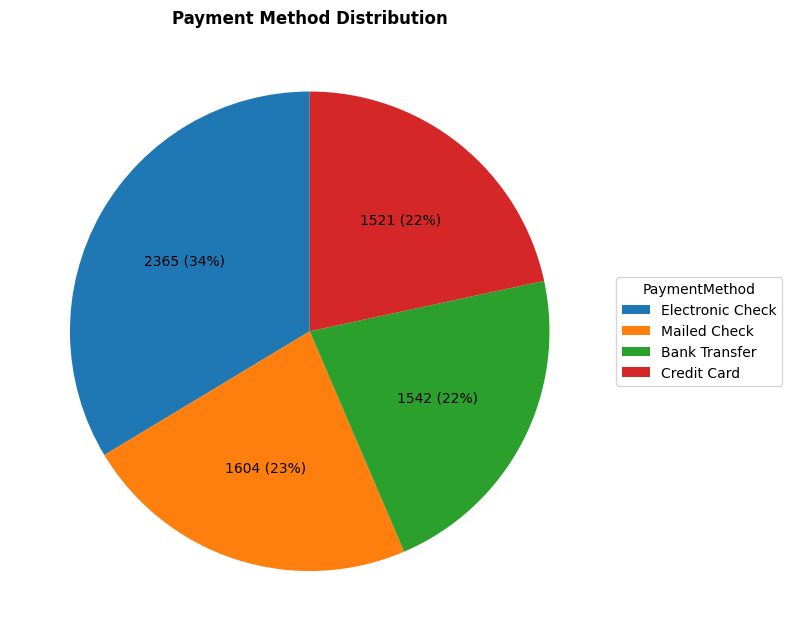

In [ ]:
pie_summary(
    data,
    column="PaymentMethod",
    title="Payment Method Distribution",
    label_map={'Electronic check': 'Electronic Check', 'Mailed check': 'Mailed Check', 'Bank transfer (automatic)': 'Bank Transfer', 'Credit card (automatic)': 'Credit Card'},
    order=['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'],
    legend_title="PaymentMethod",
)

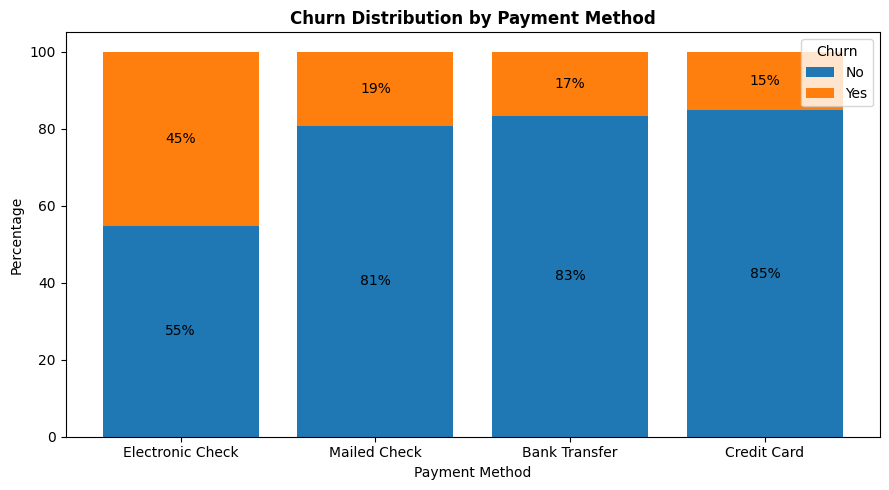

In [ ]:
stacked_churn_percent(
    data,
    column="PaymentMethod",
    title="Churn Distribution by Payment Method",
    xlabel="Payment Method",
    label_map={'Electronic check': 'Electronic Check', 'Mailed check': 'Mailed Check', 'Bank transfer (automatic)': 'Bank Transfer', 'Credit card (automatic)': 'Credit Card'},
    order=['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'],
)

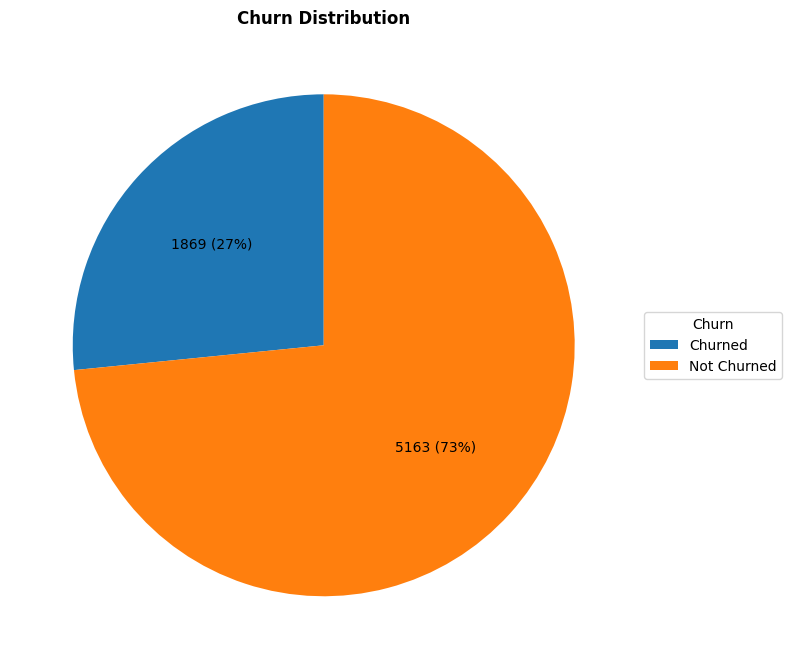

In [ ]:
pie_summary(
    data,
    column="Churn",
    title="Churn Distribution",
    label_map={'Yes': 'Churned', 'No': 'Not Churned'},
    order=['Yes', 'No'],
    legend_title="Churn",
)

## Numerical Data Visualizations

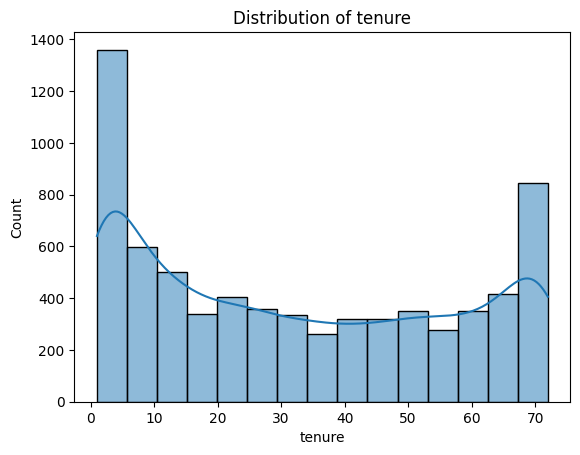

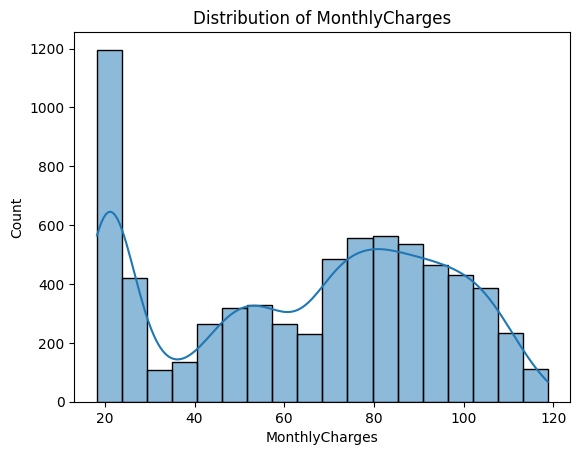

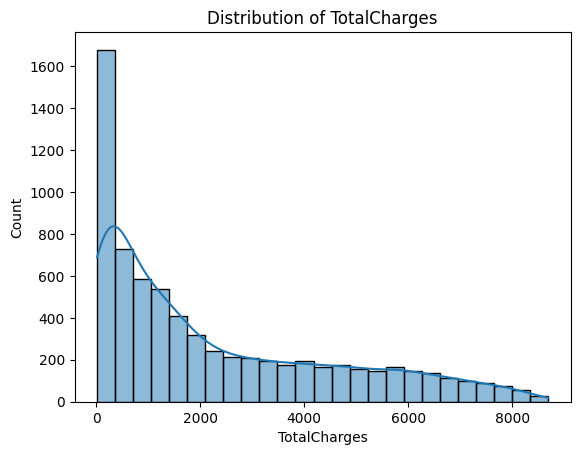

In [ ]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    plt.figure()
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
"""
Insights:
tenure → many new customers → higher churn risk
MonthlyCharges → wide variation → pricing impact
TotalCharges → right-skewed → long-term customers accumulate value
"""

'\nInsights:\ntenure → many new customers → higher churn risk\nMonthlyCharges → wide variation → pricing impact\nTotalCharges → right-skewed → long-term customers accumulate value\n'

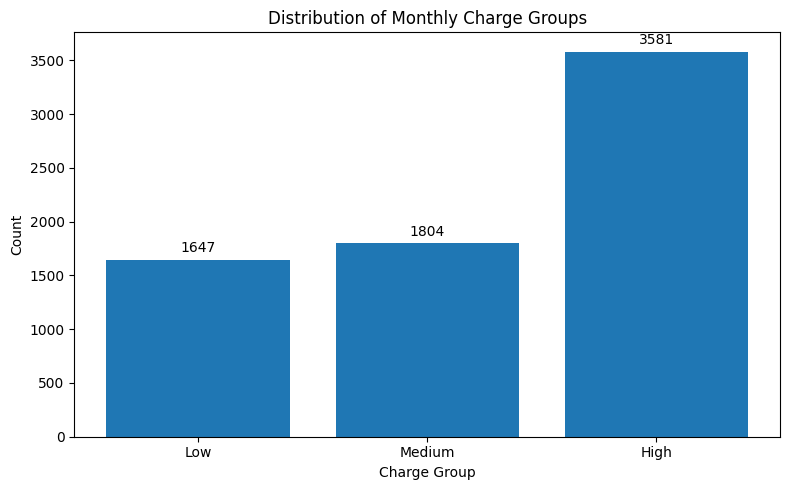

In [ ]:
# Create charge groups
data["charge_group"] = np.select(
    [
        data["MonthlyCharges"] <= 30,
        (data["MonthlyCharges"] > 30) & (data["MonthlyCharges"] <= 70),
        data["MonthlyCharges"] > 70,
    ],
    ["Low", "Medium", "High"],
    default="Unknown",
)

data["charge_group"] = pd.Categorical(
    data["charge_group"],
    categories=["Low", "Medium", "High"],
    ordered=True,
)

charge_counts = data["charge_group"].value_counts(dropna=False).sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(charge_counts.index.astype(str), charge_counts.values)
ax.bar_label(bars, padding=3)
ax.set_title("Distribution of Monthly Charge Groups", loc="center")
ax.set_xlabel("Charge Group")
ax.set_ylabel("Count")
ax.grid(False)
plt.tight_layout()
plt.show()

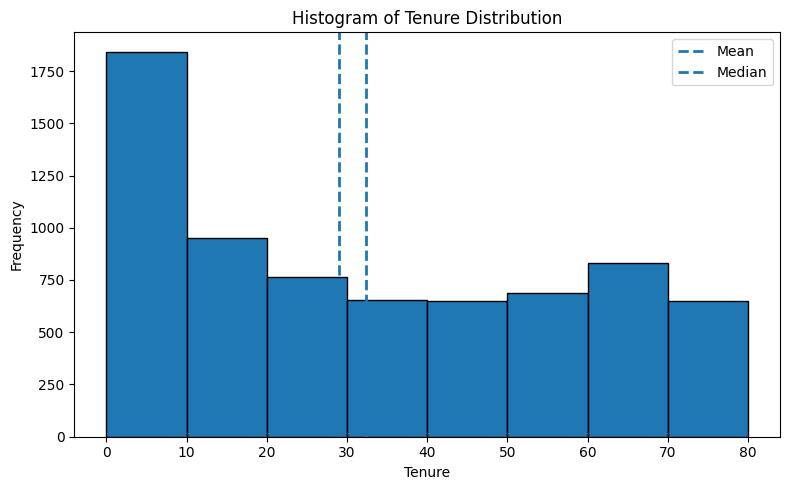

In [ ]:
mean_tenure = data["tenure"].mean()
median_tenure = data["tenure"].median()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data["tenure"], bins=np.arange(0, data["tenure"].max() + 10, 10), edgecolor="black")
ax.axvline(mean_tenure, linestyle="--", linewidth=2, label="Mean")
ax.axvline(median_tenure, linestyle="--", linewidth=2, label="Median")
ax.set_title("Histogram of Tenure Distribution", loc="center")
ax.set_xlabel("Tenure")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

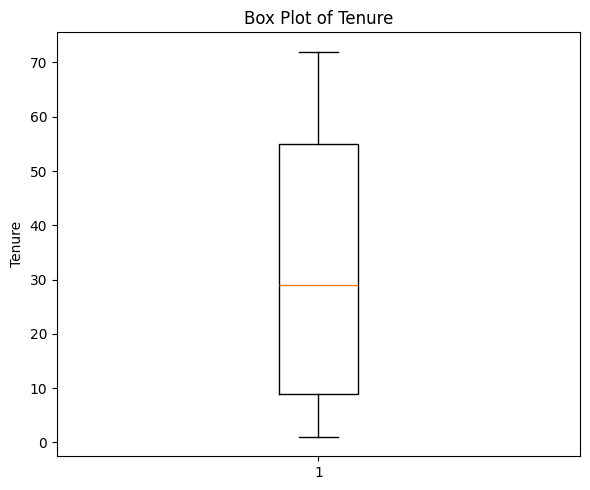

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(data["tenure"].dropna(), vert=True)
ax.set_title("Box Plot of Tenure", loc="center")
ax.set_ylabel("Tenure")
plt.tight_layout()
plt.show()

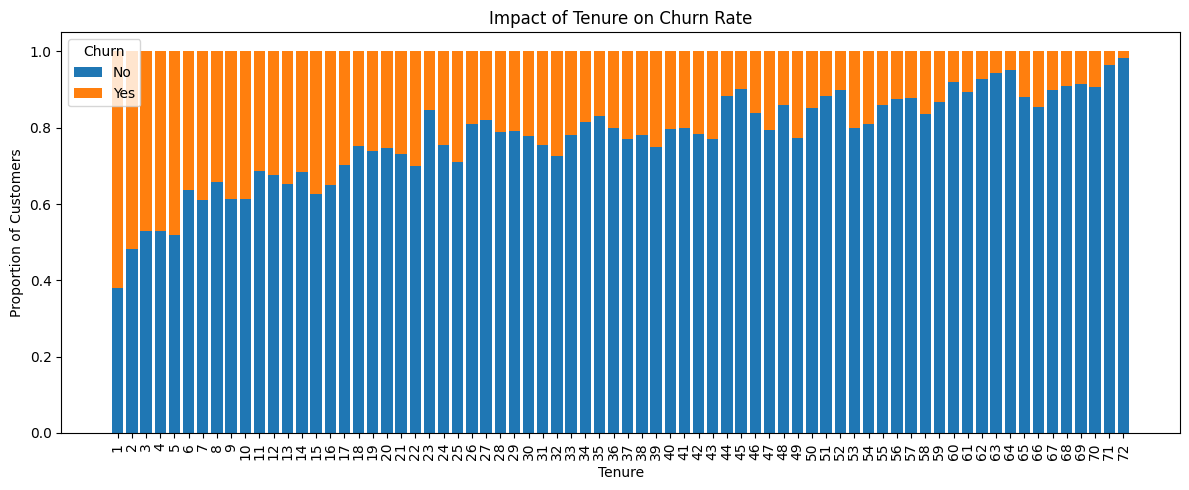

In [ ]:
tenure_churn = pd.crosstab(data["tenure"], data["Churn"], normalize="index")

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(tenure_churn))
for churn_value in tenure_churn.columns:
    values = tenure_churn[churn_value].values
    ax.bar(tenure_churn.index.astype(str), values, bottom=bottom, label=churn_value)
    bottom += values

ax.set_title("Impact of Tenure on Churn Rate", loc="center")
ax.set_xlabel("Tenure")
ax.set_ylabel("Proportion of Customers")
ax.legend(title="Churn")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

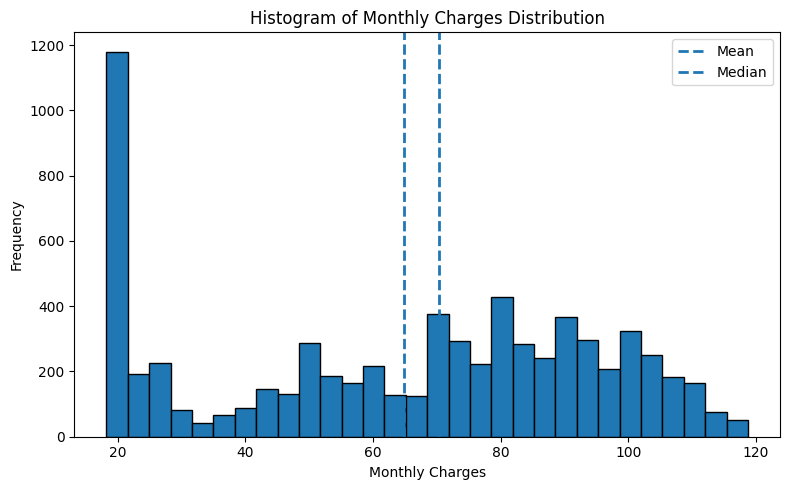

In [ ]:
mean_value = data["MonthlyCharges"].mean()
median_value = data["MonthlyCharges"].median()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data["MonthlyCharges"], bins=30, edgecolor="black")
ax.axvline(mean_value, linestyle="--", linewidth=2, label="Mean")
ax.axvline(median_value, linestyle="--", linewidth=2, label="Median")
ax.set_title("Histogram of Monthly Charges Distribution", loc="center")
ax.set_xlabel("Monthly Charges")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

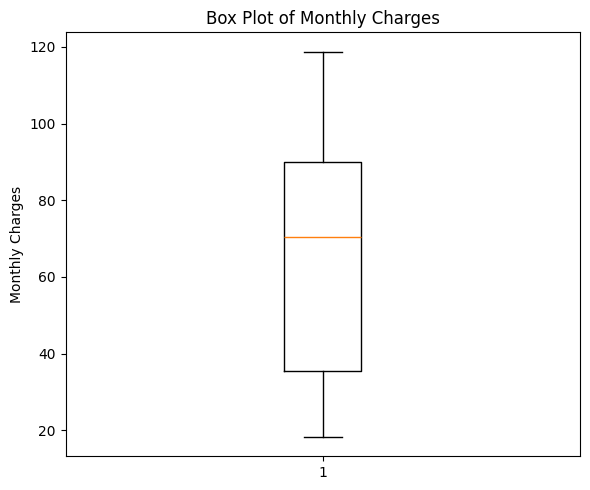

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(data["MonthlyCharges"].dropna(), vert=True)
ax.set_title("Box Plot of Monthly Charges", loc="center")
ax.set_ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

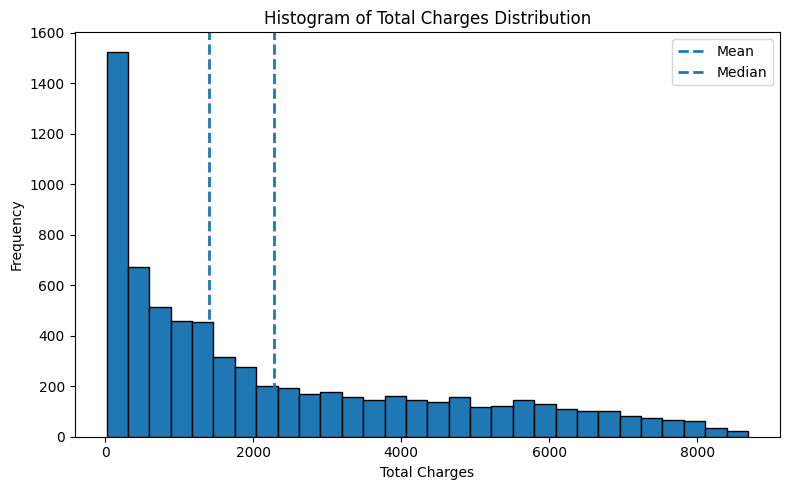

In [ ]:
mean_value = data["TotalCharges"].mean()
median_value = data["TotalCharges"].median()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(data["TotalCharges"], bins=30, edgecolor="black")
ax.axvline(mean_value, linestyle="--", linewidth=2, label="Mean")
ax.axvline(median_value, linestyle="--", linewidth=2, label="Median")
ax.set_title("Histogram of Total Charges Distribution", loc="center")
ax.set_xlabel("Total Charges")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

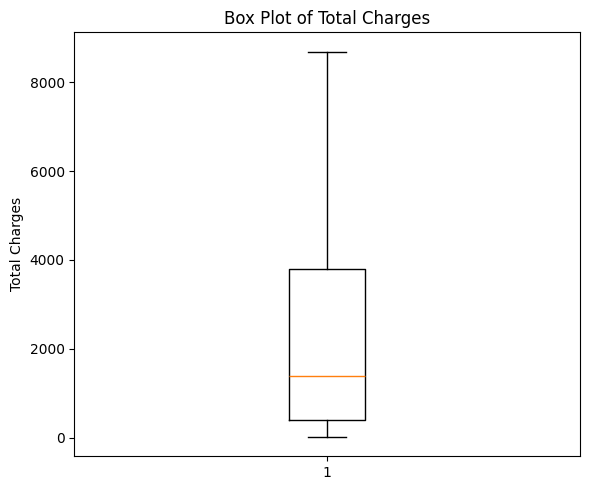

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(data["TotalCharges"].dropna(), vert=True)
ax.set_title("Box Plot of Total Charges", loc="center")
ax.set_ylabel("Total Charges")
plt.tight_layout()
plt.show()

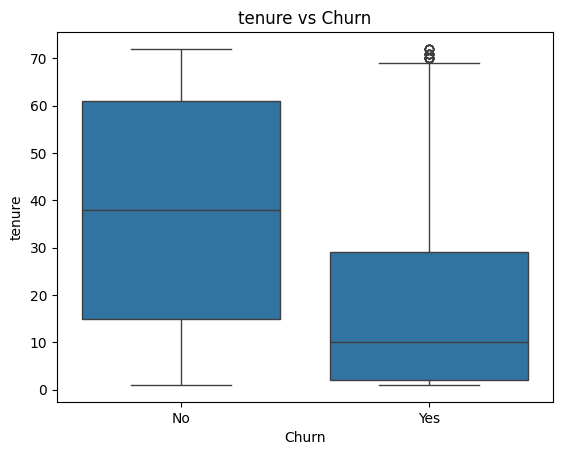

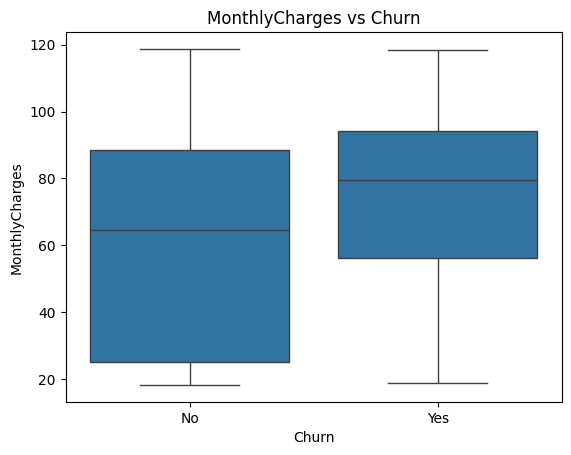

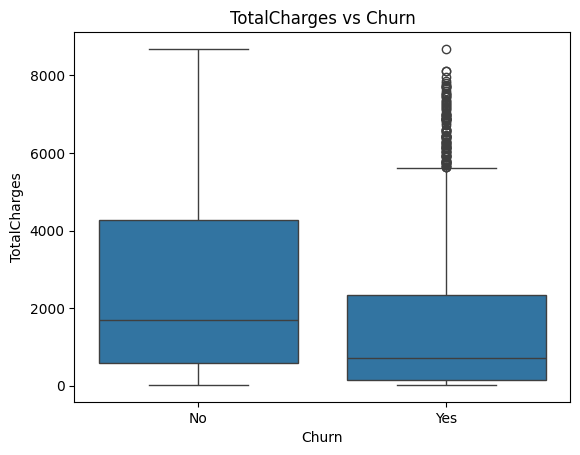

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x="Churn", y=col, data=data)
    plt.title(f"{col} vs Churn")
    plt.show()

In [ ]:
"""
Insights:
Churned customers → lower tenure
Churned customers → often higher monthly charges
Loyal customers → higher total charges (longer stay)
"""

'\nInsights:\nChurned customers → lower tenure\nChurned customers → often higher monthly charges\nLoyal customers → higher total charges (longer stay)\n'

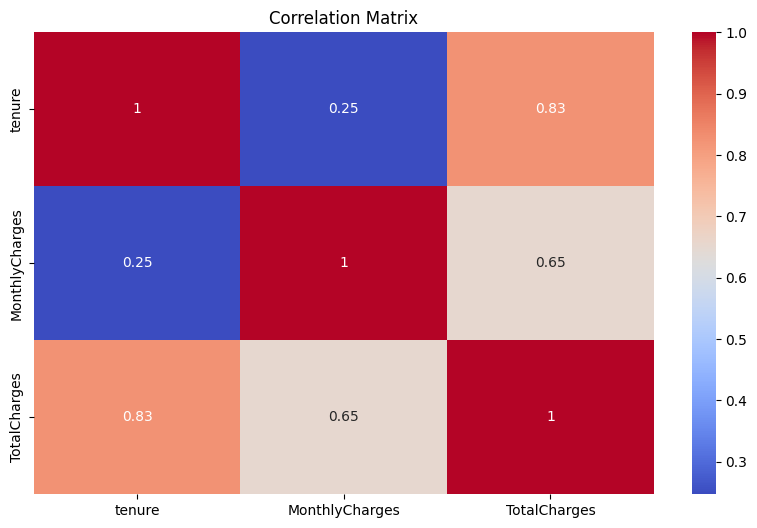

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

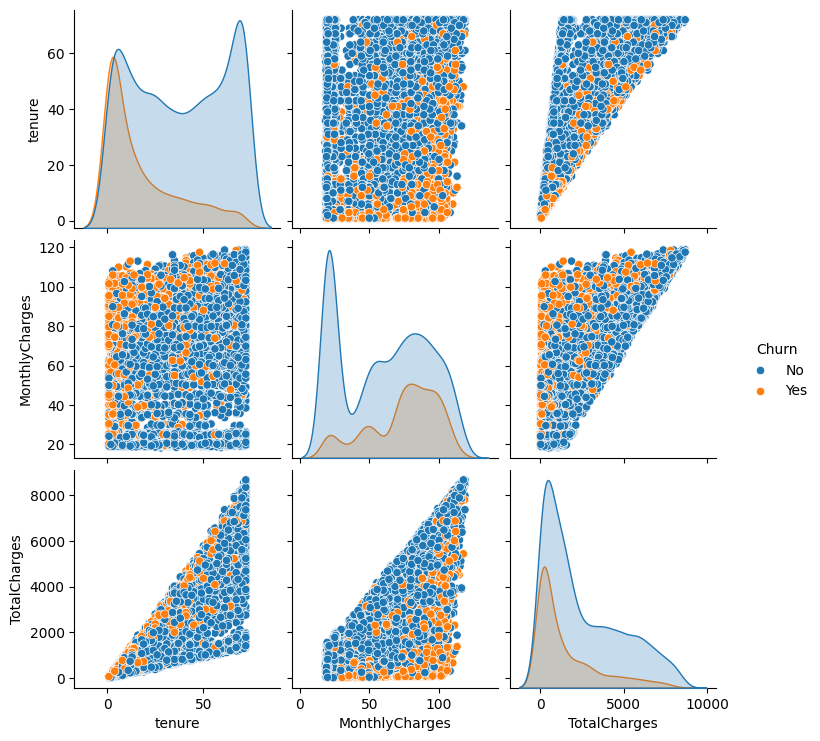

In [ ]:
sns.pairplot(data[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]], hue="Churn")
plt.show()

# Milestone 2: Advanced Data Analysis and Feature Engineering

This section extends Milestone 1 by adding statistical testing, advanced churn segmentation, feature engineering, feature selection, and model-ready transformations. These are the required components for Milestone 2: advanced analysis, engineered features, enhanced visualizations, and documentation of expected model impact.

In [ ]:
# Extra imports for Milestone 2
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Make a separate copy so Milestone 1 outputs remain unchanged
m2_data = data.copy()

# Ensure TotalCharges is numeric and clean
m2_data["TotalCharges"] = pd.to_numeric(m2_data["TotalCharges"], errors="coerce")
m2_data = m2_data.dropna().reset_index(drop=True)

# Drop customerID (not useful for modeling)
m2_data.drop("customerID", axis=1, inplace=True)

print("Milestone 2 dataset shape:", m2_data.shape)
m2_data.head()

Milestone 2 dataset shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Advanced Statistical Analysis

The goal of this section is to test whether churned and non-churned customers differ significantly across important numerical and categorical features.

In [ ]:
# T-tests for numerical features
# H0: The mean value is the same for churned and non-churned customers.
# H1: The mean value is different between churned and non-churned customers.

numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]
t_test_results = []

for col in numerical_features:
    churn_yes = m2_data[m2_data["Churn"] == "Yes"][col]
    churn_no = m2_data[m2_data["Churn"] == "No"][col]
    stat, p_value = ttest_ind(churn_yes, churn_no, equal_var=False)

    t_test_results.append({
        "Feature": col,
        "Mean_Churned": churn_yes.mean(),
        "Mean_Not_Churned": churn_no.mean(),
        "T_Statistic": stat,
        "P_Value": p_value,
        "Significant_At_0.05": p_value < 0.05
    })

t_test_df = pd.DataFrame(t_test_results)
t_test_df

,Feature,Mean_Churned,Mean_Not_Churned,T_Statistic,P_Value,Significant_At_0.05
0,tenure,17.979133,37.650010,-34.971870,2.347075e-234,True
1,MonthlyCharges,74.441332,61.307408,18.340919,2.657357e-72,True
2,TotalCharges,1531.796094,2555.344141,-18.800768,1.152494e-75,True


### T-Test Interpretation

The t-test compares the average numerical values for churned vs non-churned customers. Features with p-values below 0.05 are statistically significant and should be considered important churn predictors.

In [ ]:
# Chi-square tests for categorical features
# H0: The categorical feature and churn are independent.
# H1: The categorical feature and churn are associated.

categorical_features = [col for col in m2_data.columns if m2_data[col].dtype == "object" and col != "Churn"]
chi_square_results = []

for col in categorical_features:
    contingency_table = pd.crosstab(m2_data[col], m2_data["Churn"])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    chi_square_results.append({
        "Feature": col,
        "Chi2_Statistic": chi2,
        "P_Value": p_value,
        "Degrees_of_Freedom": dof,
        "Significant_At_0.05": p_value < 0.05
    })

chi_square_df = pd.DataFrame(chi_square_results).sort_values("P_Value")
chi_square_df

,Feature,Chi2_Statistic,P_Value,Degrees_of_Freedom,Significant_At_0.05
12,Contract,1179.545829,7.326182e-257,2,True
6,OnlineSecurity,846.677389,1.400687e-184,2,True
9,TechSupport,824.925564,7.407808e-180,2,True
5,InternetService,728.695614,5.831199e-159,2,True
14,PaymentMethod,645.429900,1.426310e-139,3,True
7,OnlineBackup,599.175185,7.776099e-131,2,True
8,DeviceProtection,555.880327,1.959389e-121,2,True
11,StreamingMovies,374.268432,5.353560e-82,2,True
10,StreamingTV,372.456502,1.324641e-81,2,True
13,PaperlessBilling,256.874908,8.236203e-58,1,True


### Chi-Square Interpretation

The chi-square test checks whether categorical variables are associated with churn. Very small p-values indicate strong evidence that the feature is related to churn behavior.

## 2. Advanced Feature Engineering

The following features are designed to capture customer loyalty, service engagement, and financial risk patterns.

In [ ]:
# Standardize service values before creating service-count features
service_columns = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

for col in service_columns:
    m2_data[col] = m2_data[col].replace({
        "No internet service": "No",
        "No phone service": "No"
    })

# 1. Tenure groups: useful for segmenting new vs loyal customers
m2_data["tenure_group"] = pd.cut(
    m2_data["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-1 Year", "1-2 Years", "2-4 Years", "4-6 Years"]
)

# 2. Total number of subscribed services: engagement/retention indicator
m2_data["TotalServices"] = m2_data[service_columns].apply(lambda row: (row == "Yes").sum(), axis=1)

# 3. Average monthly spending based on tenure-adjusted total charges
m2_data["AvgMonthlySpend"] = m2_data["TotalCharges"] / (m2_data["tenure"] + 1)

# 4. Charge per service: detects customers paying high charges for low service value
m2_data["ChargePerService"] = m2_data["MonthlyCharges"] / (m2_data["TotalServices"] + 1)

# 5. Long-term customer flag: loyalty indicator
m2_data["IsLongTerm"] = np.where(m2_data["tenure"] >= 24, 1, 0)

m2_data[["tenure", "tenure_group", "TotalServices", "AvgMonthlySpend", "ChargePerService", "IsLongTerm", "Churn"]].head()

,tenure,tenure_group,TotalServices,AvgMonthlySpend,ChargePerService,IsLongTerm,Churn
0,1,0-1 Year,1,14.925000,14.9250,0,No
1,34,2-4 Years,3,53.985714,14.2375,1,No
2,2,0-1 Year,3,36.050000,13.4625,0,Yes
3,45,2-4 Years,3,40.016304,10.5750,1,No
4,2,0-1 Year,1,50.550000,35.3500,0,Yes


In [ ]:
# Feature engineering summary table
feature_engineering_summary = pd.DataFrame({
    "New Feature": ["tenure_group", "TotalServices", "AvgMonthlySpend", "ChargePerService", "IsLongTerm"],
    "Type": ["Categorical", "Numerical", "Numerical", "Numerical", "Binary"],
    "Business Meaning": [
        "Groups customers by lifecycle stage.",
        "Measures customer engagement through subscribed services.",
        "Approximates monthly value after adjusting for tenure.",
        "Identifies customers paying high charges relative to service usage.",
        "Flags loyal customers with at least two years of tenure."
    ],
    "Expected Model Impact": [
        "Helps model capture churn risk among new customers.",
        "Higher service engagement may reduce churn risk.",
        "Highlights high-value customers and pricing sensitivity.",
        "Can detect dissatisfaction caused by poor value-for-money.",
        "Simplifies loyalty behavior into a strong binary predictor."
    ]
})

feature_engineering_summary

,New Feature,Type,Business Meaning,Expected Model Impact
0,tenure_group,Categorical,Groups customers by lifecycle stage.,Helps model capture churn risk among new custo...
1,TotalServices,Numerical,Measures customer engagement through subscribe...,Higher service engagement may reduce churn risk.
2,AvgMonthlySpend,Numerical,Approximates monthly value after adjusting for...,Highlights high-value customers and pricing se...
3,ChargePerService,Numerical,Identifies customers paying high charges relat...,Can detect dissatisfaction caused by poor valu...
4,IsLongTerm,Binary,Flags loyal customers with at least two years ...,Simplifies loyalty behavior into a strong bina...


## 3. Enhanced Churn Visualizations

These charts focus on business interpretation, customer segmentation, and churn drivers.

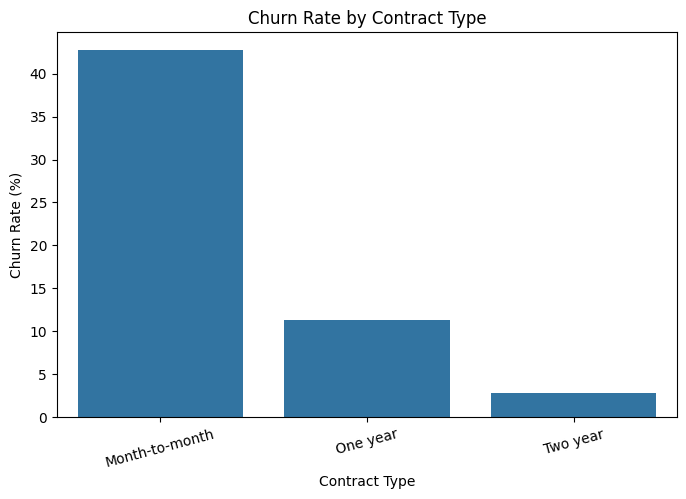

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [ ]:
# Churn rate by contract type
contract_churn = pd.crosstab(m2_data["Contract"], m2_data["Churn"], normalize="index") * 100
contract_churn = contract_churn.sort_values("Yes", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=contract_churn.index, y=contract_churn["Yes"])
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Contract Type")
plt.xticks(rotation=15)
plt.show()

contract_churn

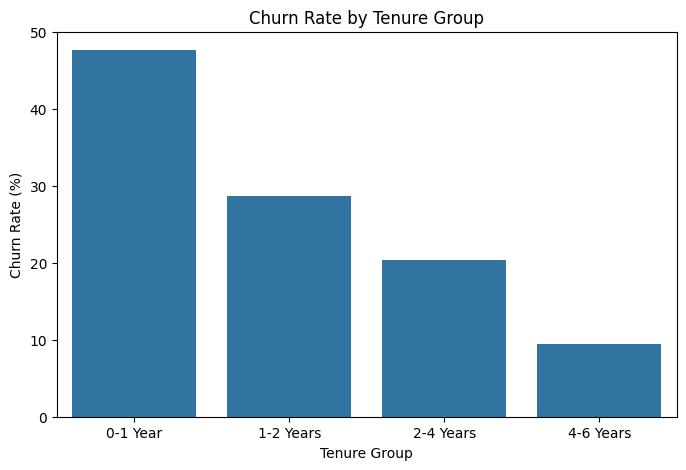

Churn,No,Yes
tenure_group,,
0-1 Year,52.321839,47.678161
1-2 Years,71.289062,28.710938
2-4 Years,79.611041,20.388959
4-6 Years,90.486824,9.513176


In [ ]:
# Churn rate by tenure group
tenure_group_churn = pd.crosstab(m2_data["tenure_group"], m2_data["Churn"], normalize="index") * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=tenure_group_churn.index, y=tenure_group_churn["Yes"])
plt.title("Churn Rate by Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Tenure Group")
plt.show()

tenure_group_churn

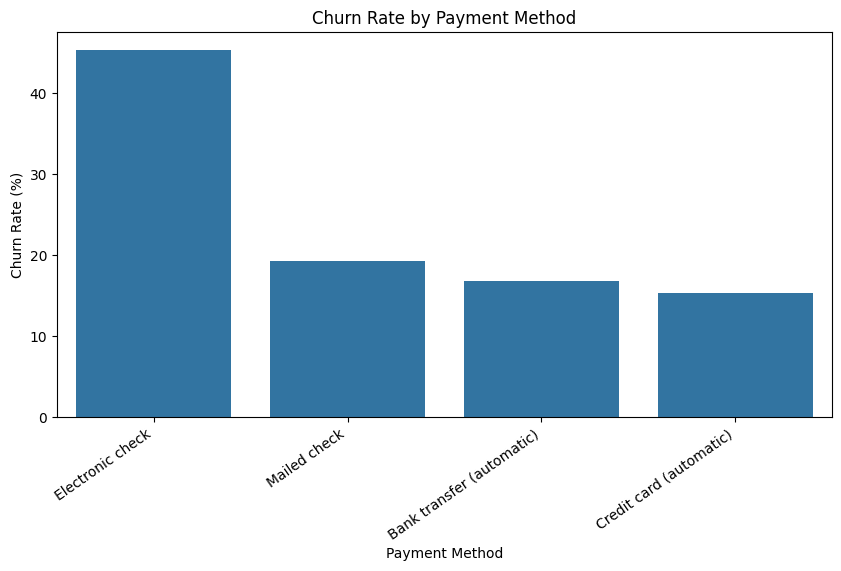

Churn,No,Yes
PaymentMethod,,
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123


In [ ]:
# Churn rate by payment method
payment_churn = pd.crosstab(m2_data["PaymentMethod"], m2_data["Churn"], normalize="index") * 100
payment_churn = payment_churn.sort_values("Yes", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=payment_churn.index, y=payment_churn["Yes"])
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Payment Method")
plt.xticks(rotation=35, ha="right")
plt.show()

payment_churn

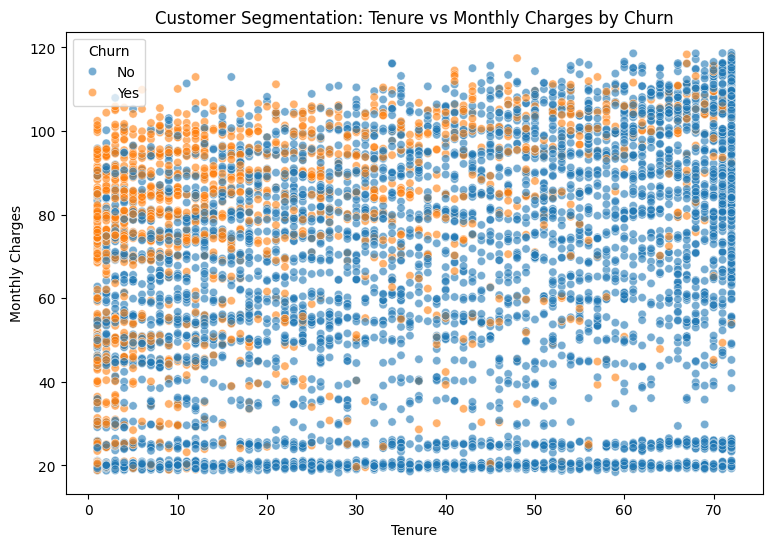

In [ ]:
# Monthly charges and tenure segmentation by churn
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=m2_data,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.6
)
plt.title("Customer Segmentation: Tenure vs Monthly Charges by Churn")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.show()

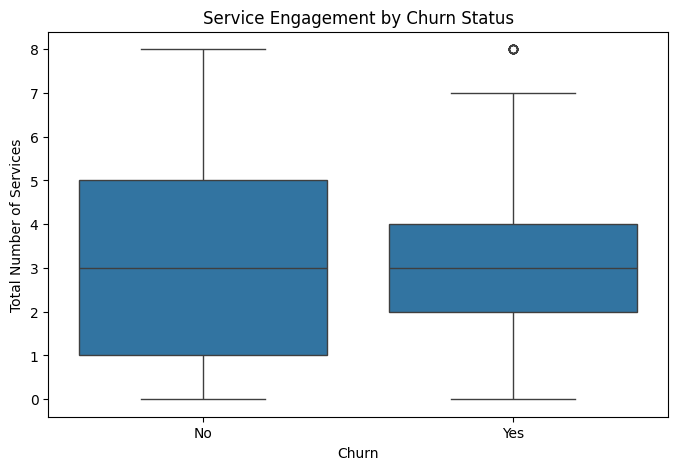

,TotalServices,MonthlyCharges,AvgMonthlySpend,ChargePerService
Churn,,,,
No,3.447027,61.307408,57.779786,13.999997
Yes,3.132156,74.441332,62.683301,19.321059


In [ ]:
# Service engagement vs churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=m2_data, x="Churn", y="TotalServices")
plt.title("Service Engagement by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Number of Services")
plt.show()

m2_data.groupby("Churn")[["TotalServices", "MonthlyCharges", "AvgMonthlySpend", "ChargePerService"]].mean()

## 4. Encoding, Scaling, and Model-Ready Dataset

This section prepares the engineered dataset for feature selection and the next milestone.

In [ ]:
# Prepare encoded model-ready data
model_data = m2_data.copy()

# Encode target
model_data["Churn"] = model_data["Churn"].map({"No": 0, "Yes": 1})

# One-hot encode categorical features
encoded_data = pd.get_dummies(model_data, drop_first=True)

# Scale numeric features that have different ranges
scale_columns = [
    "tenure", "MonthlyCharges", "TotalCharges",
    "AvgMonthlySpend", "TotalServices", "ChargePerService"
]

scaler = StandardScaler()
encoded_data[scale_columns] = scaler.fit_transform(encoded_data[scale_columns])

print("Encoded dataset shape:", encoded_data.shape)
encoded_data.head()

Encoded dataset shape: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,TotalServices,AvgMonthlySpend,ChargePerService,IsLongTerm,gender_Male,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2 Years,tenure_group_2-4 Years,tenure_group_4-6 Years
0,0,-1.280248,-1.161694,-0.994194,0,-1.146183,-1.447223,-0.081687,0,False,...,False,False,False,True,False,True,False,False,False,False
1,0,0.064303,-0.260878,-0.173740,0,-0.176214,-0.167059,-0.196473,1,True,...,False,True,False,False,False,False,True,False,True,False
2,0,-1.239504,-0.363923,-0.959649,1,-0.176214,-0.754879,-0.325869,0,True,...,False,False,False,True,False,False,True,False,False,False
3,0,0.512486,-0.747850,-0.195248,0,-0.176214,-0.624888,-0.807971,1,True,...,False,True,False,False,False,False,False,False,True,False
4,0,-1.239504,0.196178,-0.940457,1,-1.146183,-0.279660,3.328510,0,False,...,False,False,False,True,False,True,False,False,False,False


## 5. Feature Selection

Feature selection identifies which variables are most useful for churn prediction. This section uses correlation, RFE, and Random Forest feature importance.

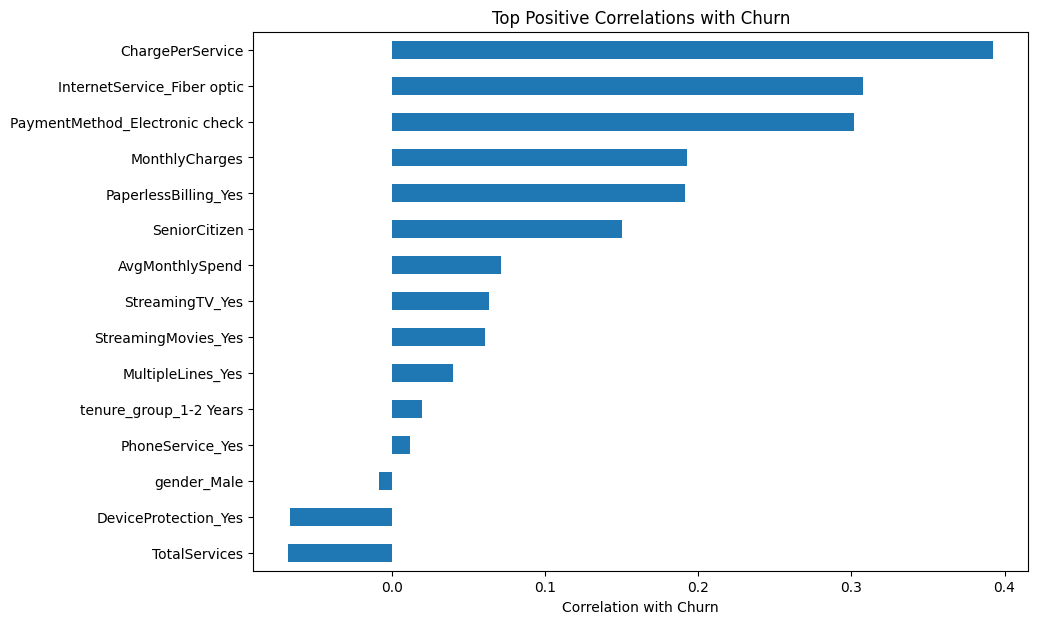

,Churn
Churn,1.000000
ChargePerService,0.392457
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
MonthlyCharges,0.192858
PaperlessBilling_Yes,0.191454
SeniorCitizen,0.150541
AvgMonthlySpend,0.070992
StreamingTV_Yes,0.063254
StreamingMovies_Yes,0.060860


In [ ]:
# Correlation with churn
correlation_with_churn = encoded_data.corr()["Churn"].sort_values(ascending=False)

plt.figure(figsize=(10, 7))
correlation_with_churn.drop("Churn").head(15).sort_values().plot(kind="barh")
plt.title("Top Positive Correlations with Churn")
plt.xlabel("Correlation with Churn")
plt.show()

correlation_with_churn.head(15)

In [ ]:
# Recursive Feature Elimination using Logistic Regression
X = encoded_data.drop("Churn", axis=1)
y = encoded_data["Churn"]

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", solver="liblinear")
rfe = RFE(estimator=log_reg, n_features_to_select=12, step=0.2)
rfe.fit(X, y)

rfe_selected_features = pd.DataFrame({
    "Feature": X.columns,
    "Selected_By_RFE": rfe.support_,
    "RFE_Ranking": rfe.ranking_
}).sort_values(["Selected_By_RFE", "RFE_Ranking"], ascending=[False, True])

rfe_selected_features.head(20)

,Feature,Selected_By_RFE,RFE_Ranking
1,tenure,True,1
2,MonthlyCharges,True,1
3,TotalCharges,True,1
5,AvgMonthlySpend,True,1
12,MultipleLines_Yes,True,1
13,InternetService_Fiber optic,True,1
14,InternetService_No,True,1
19,StreamingTV_Yes,True,1
20,StreamingMovies_Yes,True,1
21,Contract_One year,True,1


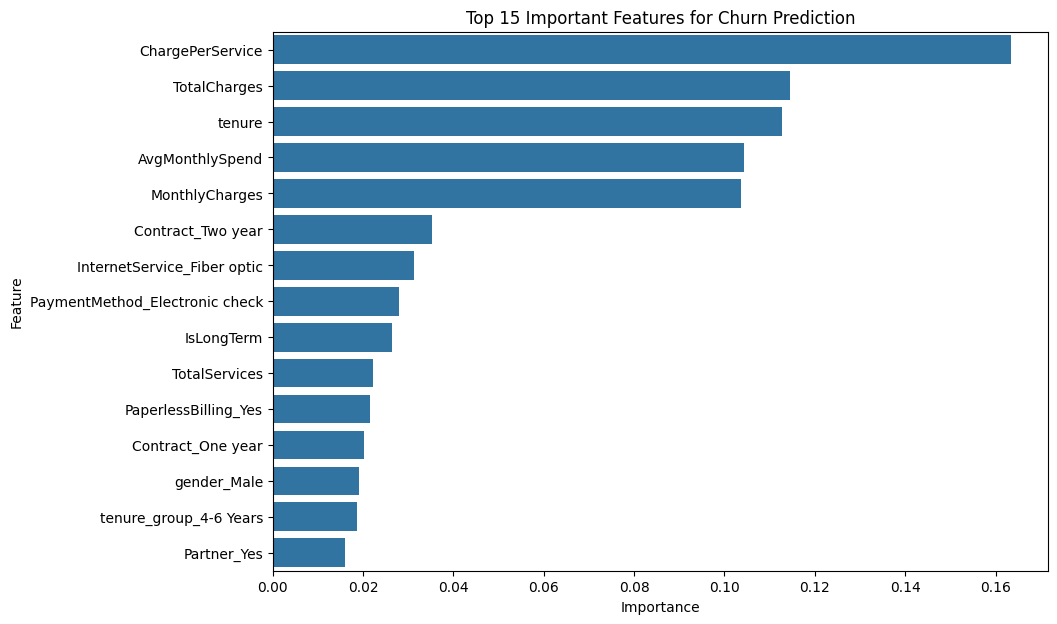

,Feature,Importance
6,ChargePerService,0.163399
3,TotalCharges,0.114551
1,tenure,0.112836
5,AvgMonthlySpend,0.104214
2,MonthlyCharges,0.103621
22,Contract_Two year,0.035239
13,InternetService_Fiber optic,0.031217
25,PaymentMethod_Electronic check,0.027833
7,IsLongTerm,0.026380
4,TotalServices,0.022185


In [ ]:
# Random Forest feature importance
rf = RandomForestClassifier(
    n_estimators=120,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance.head(15), x="Importance", y="Feature")
plt.title("Top 15 Important Features for Churn Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

feature_importance.head(15)

## 6. Milestone 2 Business Insights

Based on the advanced analysis and feature engineering:

1. **Contract type is one of the strongest churn drivers.** Month-to-month customers show a much higher churn rate than one-year and two-year contract customers.
2. **Tenure strongly affects churn.** Customers in the first year have the highest churn risk, while long-term customers are much more stable.
3. **Monthly charges are higher for churned customers.** This suggests possible pricing sensitivity or perceived low value.
4. **Service engagement matters.** Customers using more services are usually more embedded in the company ecosystem and are less likely to leave.
5. **Support and security services are important retention indicators.** Lack of tech support and online security is strongly associated with churn.
6. **Payment method is a behavioral risk signal.** Electronic check customers have a higher churn tendency.
7. **Engineered features such as TotalServices, ChargePerService, AvgMonthlySpend, tenure_group, and IsLongTerm improve the model’s ability to capture customer value, engagement, and loyalty.**